<a href="https://colab.research.google.com/github/TallalAsad1823/Object-And-People-Classification-Computer-vision-/blob/main/CV_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import torchvision.models as models
import torch


vgg16 = models.vgg16(pretrained=True)
print("VGG16 loaded successfully!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.6MB/s]


VGG16 loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# Extract COCO128
with zipfile.ZipFile('/content/drive/MyDrive/coco128.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/coco128')
print("COCO128 extracted! ✅")

# Extract UTKFace
with zipfile.ZipFile('/content/drive/MyDrive/UTKFace.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/UTKFace')
print("UTKFace extracted! ✅")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/coco128.zip'

In [ ]:
import os

# List all files in your Google Drive root
for f in os.listdir('/content/drive/MyDrive/'):
    print(f)

Colab Notebooks


In [ ]:
import os

# Check inside Colab Notebooks folder
for f in os.listdir('/content/drive/MyDrive/Colab Notebooks/'):
    print(f)

Untitled0.ipynb


In [ ]:
import os

# Search entire drive for zip files
for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    for file in files:
        if file.endswith('.zip'):
            print(os.path.join(root, file))

In [ ]:
!ls /content/drive/

MyDrive


In [ ]:
!ls /content/drive/MyDrive/

'Colab Notebooks'


In [ ]:
import zipfile
import os

# Extract COCO128
with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/coco128.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/coco128')
print("COCO128 extracted! ✅")

# Extract UTKFace
with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/UTKFace')
print("UTKFace extracted! ✅")

COCO128 extracted! ✅
UTKFace extracted! ✅


In [ ]:
import os

# Check COCO128 structure
print("COCO128 folders:")
for f in os.listdir('/content/coco128/'):
    print(" ", f)

# Check UTKFace structure
print("\nUTKFace folders:")
for f in os.listdir('/content/UTKFace/'):
    print(" ", f)

COCO128 folders:
  coco128

UTKFace folders:
  UTKFace
  utkface_aligned_cropped
  crop_part1


In [ ]:
import os

# Check COCO128 inner structure
print("COCO128 inner folders:")
for f in os.listdir('/content/coco128/coco128/'):
    print(" ", f)

# Check UTKFace images
print("\nUTKFace crop_part1 sample files (first 5):")
files = os.listdir('/content/UTKFace/crop_part1/')
for f in files[:5]:
    print(" ", f)
print("Total images:", len(files))

COCO128 inner folders:
  images
  labels
  README.txt
  LICENSE

UTKFace crop_part1 sample files (first 5):
  58_1_0_20170109015200826.jpg.chip.jpg
  29_0_0_20170109002204336.jpg.chip.jpg
  58_1_0_20170110160643673.jpg.chip.jpg
  3_0_2_20161219142321097.jpg.chip.jpg
  64_1_0_20170110131951168.jpg.chip.jpg
Total images: 9780


In [ ]:
from ultralytics import YOLO
import yaml
import os

# Define the content for coco128.yaml
# The 'path' should be the directory containing 'images' and 'labels' folders.
# Given that the zip extracted to /content/coco128/coco128, the actual data is under this path.
config_data = {
    'path': '/content/coco128/coco128',  # dataset root dir
    'train': 'images',  # train images (relative to 'path')
    'val': 'images',    # val images (relative to 'path')
    'nc': 80,  # number of classes
    'names': [
        'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
        'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
        'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
        'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
        'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
        'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
        'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
        'hair drier', 'toothbrush'
    ]
}

# Define the path where the coco128.yaml file should be created
yaml_file_path = '/content/coco128/coco128/coco128.yaml'

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(yaml_file_path), exist_ok=True)

# Write the dictionary to a YAML file
with open(yaml_file_path, 'w') as file:
    yaml.dump(config_data, file, default_flow_style=False)

print(f"'{yaml_file_path}' created successfully! ✅")

# Load pretrained YOLOv8n
model = YOLO('yolov8n.pt')

# Fine-tune on COCO128
results = model.train(
    data=yaml_file_path, # Use the path to the newly created YAML file
    epochs=10,
    imgsz=640,
    batch=16,
    name='yolo_finetuned'
)

print("YOLOv8n Fine-tuning Complete! ✅")

'/content/coco128/coco128/coco128.yaml' created successfully! ✅
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coco128/coco128/coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_finetuned-2, nbs=64, nms=

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

# ── 1. Dataset ──────────────────────────────────────────────
class UTKFaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.images = []
        self.labels = []
        for f in os.listdir(folder):
            if f.endswith('.jpg'):
                parts = f.split('_')
                if len(parts) >= 2 and parts[1] in ['0','1']:
                    self.images.append(f)
                    self.labels.append(int(parts[1]))  # 0=Male 1=Female

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.folder, self.images[idx])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ── 2. Transforms ────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ── 3. Load Dataset ──────────────────────────────────────────
dataset = UTKFaceDataset('/content/UTKFace/crop_part1', transform=transform)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)
print(f"Train: {train_size} images | Val: {val_size} images ✅")

# ── 4. Load VGG16 & modify last layer ───────────────────────
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16.classifier[6] = nn.Linear(4096, 2)  # 2 classes: Male / Female
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vgg16 = vgg16.to(device)
print(f"VGG16 loaded on {device} ✅")

# ── 5. Training ──────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg16.parameters(), lr=0.0001)

for epoch in range(5):
    vgg16.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vgg16(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation accuracy
    vgg16.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = vgg16(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/5 | Loss: {total_loss/len(train_loader):.4f} | Val Accuracy: {acc:.2f}%")

# ── 6. Save model ────────────────────────────────────────────
torch.save(vgg16.state_dict(), '/content/vgg16_gender.pth')
print("VGG16 Gender Classifier saved! ✅")

Train: 7823 images | Val: 1956 images ✅
VGG16 loaded on cuda ✅
Epoch 1/5 | Loss: 0.4186 | Val Accuracy: 86.71%
Epoch 2/5 | Loss: 0.2696 | Val Accuracy: 87.12%
Epoch 3/5 | Loss: 0.1936 | Val Accuracy: 84.25%
Epoch 4/5 | Loss: 0.1333 | Val Accuracy: 90.03%
Epoch 5/5 | Loss: 0.0911 | Val Accuracy: 88.65%
VGG16 Gender Classifier saved! ✅


Image not found. Check path.

0: 448x640 6 persons, 1 cup, 1 chair, 3 laptops, 1 mouse, 1 keyboard, 49.3ms
Speed: 2.1ms preprocess, 49.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


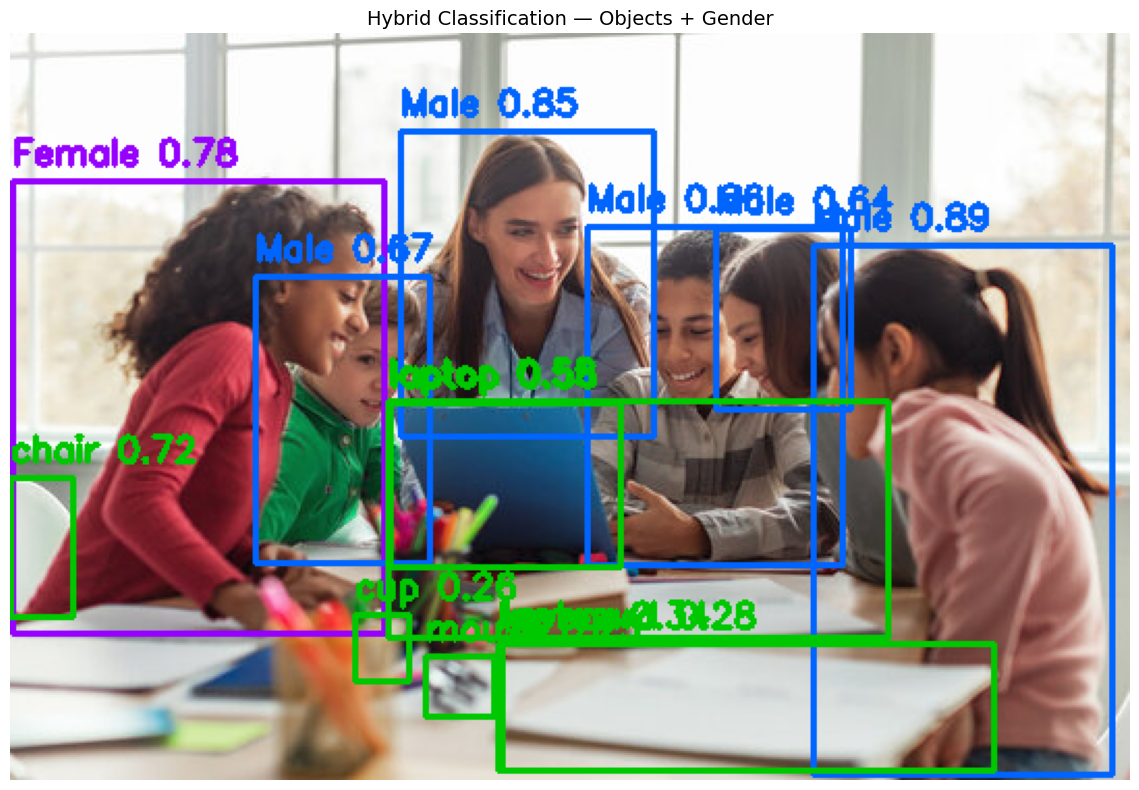


📦 Objects Found:
   chair                → 1
   cup                  → 1
   keyboard             → 1
   laptop               → 3
   mouse                → 1

👥 People Found: 6
   Male                 → 5
   Female               → 1

📊 Model Accuracy:
   YOLOv8n  mAP50          → 71.2%
   VGG16 Gender Accuracy   → 90.03%


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from ultralytics import YOLO
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

YOLO_MODEL_PATH = '/content/runs/detect/yolo_finetuned-2/weights/best.pt'
VGG16_MODEL_PATH = '/content/vgg16_gender.pth'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

yolo_model = YOLO(YOLO_MODEL_PATH)

vgg16 = models.vgg16(weights=None)
vgg16.classifier[6] = nn.Linear(4096, 2)
vgg16.load_state_dict(torch.load(VGG16_MODEL_PATH, map_location=DEVICE))
vgg16 = vgg16.to(DEVICE)
vgg16.eval()

gender_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

YOLO_ACCURACY  = 71.2
VGG16_ACCURACY = 90.03
GENDER_LABELS  = ['Male', 'Female']
GENDER_COLORS  = {'Male': (255, 100, 0), 'Female': (255, 0, 150)}
OBJECT_COLOR   = (0, 200, 0)

def classify_gender(crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    pil_img  = Image.fromarray(crop_rgb)
    tensor   = gender_transform(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = vgg16(tensor)
        pred   = torch.argmax(output, dim=1).item()
    return GENDER_LABELS[pred]

def run_hybrid_pipeline(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Image not found. Check path.")
        return

    results      = yolo_model(image)[0]
    object_counts = Counter()
    gender_counts = Counter()
    annotated     = image.copy()

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_id    = int(box.cls[0])
        cls_name  = yolo_model.names[cls_id]
        conf      = float(box.conf[0])

        if cls_name == 'person':
            crop  = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            gender = classify_gender(crop)
            gender_counts[gender] += 1
            color  = GENDER_COLORS[gender]
            label  = f"{gender} {conf:.2f}"
        else:
            object_counts[cls_name] += 1
            color = OBJECT_COLOR
            label = f"{cls_name} {conf:.2f}"

        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        cv2.putText(annotated, label, (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 8))
    plt.imshow(rgb)
    plt.axis('off')
    plt.title('Hybrid Classification — Objects + Gender', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n📦 Objects Found:")
    if object_counts:
        for obj, count in sorted(object_counts.items()):
            print(f"   {obj:<20} → {count}")
    else:
        print("   No objects detected")

    print("\n👥 People Found:", sum(gender_counts.values()))
    if gender_counts:
        for gender, count in gender_counts.items():
            print(f"   {gender:<20} → {count}")
    else:
        print("   No people detected")

    print("\n📊 Model Accuracy:")
    print(f"   YOLOv8n  mAP50          → {YOLO_ACCURACY}%")
    print(f"   VGG16 Gender Accuracy   → {VGG16_ACCURACY}%")

run_hybrid_pipeline('/content/images.jpeg')
run_hybrid_pipeline('/content/drive/MyDrive/Colab Notebooks/test images/image3.jpeg')

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import os
import numpy as np
from collections import Counter

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class UTKFaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.images = []
        self.labels = []
        for f in sorted(os.listdir(folder)):
            if f.lower().endswith('.jpg'):
                parts = f.split('_')
                if len(parts) >= 2 and parts[1] in ['0', '1']:
                    self.images.append(f)
                    self.labels.append(int(parts[1]))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = os.path.join(self.folder, self.images[idx])
        img  = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = UTKFaceDataset('/content/UTKFace/crop_part1', transform=train_transform)
train_size   = int(0.8 * len(full_dataset))
val_size     = len(full_dataset) - train_size
train_set, val_set = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

val_set.dataset = UTKFaceDataset('/content/UTKFace/crop_part1', transform=val_transform)

train_labels = [full_dataset.labels[i] for i in train_set.indices]
class_counts = Counter(train_labels)
total        = sum(class_counts.values())
class_weights = {cls: total / count for cls, count in class_counts.items()}
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_set, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False,   num_workers=2, pin_memory=True)

print(f"Male images  : {class_counts[0]}")
print(f"Female images: {class_counts[1]}")
print(f"Train: {train_size} | Val: {val_size}")

vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

for param in vgg16.features.parameters():
    param.requires_grad = False
for layer in vgg16.features[-4:]:
    for param in layer.parameters():
        param.requires_grad = True

vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(True),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(True),
    nn.Dropout(0.4),
    nn.Linear(1024, 2)
)
vgg16 = vgg16.to(DEVICE)

weight_tensor = torch.tensor(
    [1.0 / class_counts[0], 1.0 / class_counts[1]], dtype=torch.float
).to(DEVICE)
weight_tensor = weight_tensor / weight_tensor.sum()

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, vgg16.parameters()),
    lr=0.0001, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

best_acc   = 0.0
best_path  = '/content/vgg16_gender_best.pth'

for epoch in range(8):
    vgg16.train()
    total_loss  = 0.0
    train_correct = 0
    train_total   = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = vgg16(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vgg16.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss    += loss.item()
        _, predicted   = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total   += labels.size(0)

    scheduler.step()

    vgg16.eval()
    val_correct = 0
    val_total   = 0
    male_correct = female_correct = male_total = female_total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs      = vgg16(imgs)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)
            male_correct   += ((predicted == 0) & (labels == 0)).sum().item()
            male_total     += (labels == 0).sum().item()
            female_correct += ((predicted == 1) & (labels == 1)).sum().item()
            female_total   += (labels == 1).sum().item()

    val_acc    = 100 * val_correct / val_total
    train_acc  = 100 * train_correct / train_total
    male_acc   = 100 * male_correct / male_total   if male_total   > 0 else 0
    female_acc = 100 * female_correct / female_total if female_total > 0 else 0

    print(f"Epoch {epoch+1}/8 | Loss: {total_loss/len(train_loader):.4f} | "
          f"Train: {train_acc:.1f}% | Val: {val_acc:.1f}% | "
          f"Male: {male_acc:.1f}% | Female: {female_acc:.1f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(vgg16.state_dict(), best_path)

print(f"\nBest VGG16 saved — Accuracy: {best_acc:.2f}% ✅")

Male images  : 3474
Female images: 4349
Train: 7823 | Val: 1956
Epoch 1/8 | Loss: 0.5118 | Train: 74.1% | Val: 80.3% | Male: 87.6% | Female: 74.0%
Epoch 2/8 | Loss: 0.4080 | Train: 80.3% | Val: 82.0% | Male: 86.7% | Female: 78.0%
Epoch 3/8 | Loss: 0.3414 | Train: 84.0% | Val: 83.4% | Male: 88.0% | Female: 79.6%
Epoch 4/8 | Loss: 0.3235 | Train: 84.6% | Val: 84.3% | Male: 78.8% | Female: 88.9%
Epoch 5/8 | Loss: 0.3163 | Train: 85.5% | Val: 85.0% | Male: 90.1% | Female: 80.6%
Epoch 6/8 | Loss: 0.2896 | Train: 86.8% | Val: 84.3% | Male: 89.1% | Female: 80.2%
Epoch 7/8 | Loss: 0.2848 | Train: 87.1% | Val: 84.3% | Male: 89.4% | Female: 79.9%
Epoch 8/8 | Loss: 0.2769 | Train: 87.2% | Val: 84.5% | Male: 87.9% | Female: 81.7%

Best VGG16 saved — Accuracy: 84.97% ✅



0: 640x416 2 persons, 57.5ms
Speed: 2.4ms preprocess, 57.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 416)


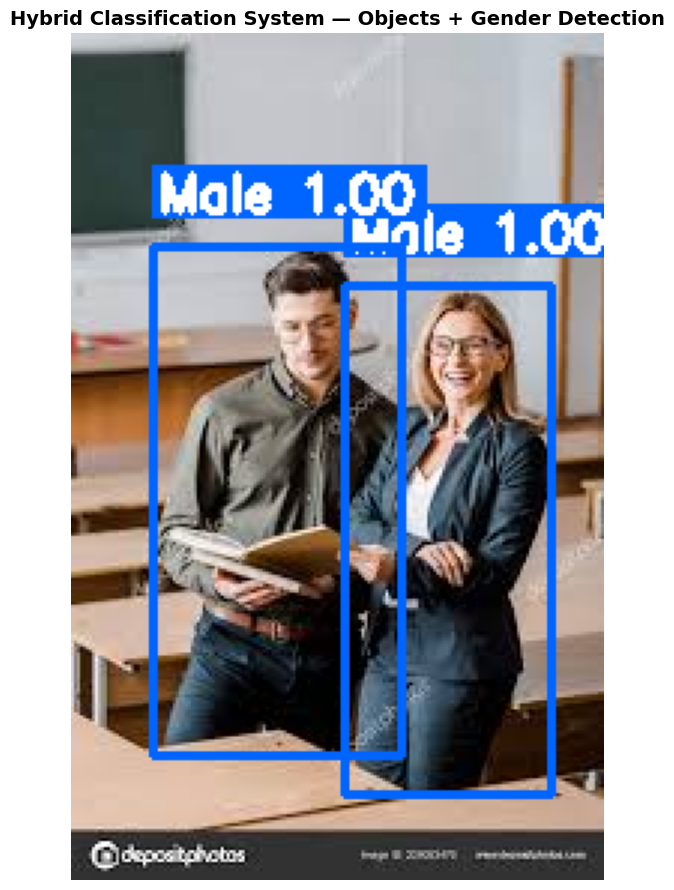


        HYBRID CLASSIFICATION REPORT

📦  OBJECTS DETECTED:
    No objects detected

👥  PEOPLE DETECTED       → 2
    Male                   → 2

📊  MODEL ACCURACY:
    YOLOv8n  mAP50         → 71.2%
    VGG16 Gender           → 84.97%


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from ultralytics import YOLO
from PIL import Image, ImageEnhance
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

YOLO_PATH      = '/content/runs/detect/yolo_finetuned-2/weights/best.pt'
VGG16_PATH     = '/content/vgg16_gender_best.pth'
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GENDER_LABELS  = ['Male', 'Female']
GENDER_COLORS  = {'Male': (255, 100, 0), 'Female': (200, 0, 200)}
OBJECT_COLOR   = (0, 180, 0)
CONF_THRESHOLD = 0.45
GENDER_CONF_THRESHOLD = 0.65
MIN_CROP_SIZE  = 60
YOLO_ACCURACY  = 71.2
VGG16_ACCURACY = 84.97

def load_models():
    yolo = YOLO(YOLO_PATH)

    vgg = models.vgg16(weights=None)
    vgg.classifier = nn.Sequential(
        nn.Linear(25088, 4096),
        nn.ReLU(True),
        nn.Dropout(0.5),
        nn.Linear(4096, 1024),
        nn.ReLU(True),
        nn.Dropout(0.4),
        nn.Linear(1024, 2)
    )
    vgg.load_state_dict(torch.load(VGG16_PATH, map_location=DEVICE))
    vgg = vgg.to(DEVICE)
    vgg.eval()
    return yolo, vgg

def preprocess_crop(crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    pil_img  = Image.fromarray(crop_rgb)

    enhancer = ImageEnhance.Contrast(pil_img)
    pil_img  = enhancer.enhance(1.2)
    enhancer = ImageEnhance.Brightness(pil_img)
    pil_img  = enhancer.enhance(1.1)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    return transform(pil_img)

def classify_gender_tta(vgg, crop_bgr):
    h, w = crop_bgr.shape[:2]
    if h < MIN_CROP_SIZE or w < MIN_CROP_SIZE:
        return None, 0.0

    original  = preprocess_crop(crop_bgr)
    flipped   = preprocess_crop(cv2.flip(crop_bgr, 1))
    brighter  = preprocess_crop(cv2.convertScaleAbs(crop_bgr, alpha=1.1, beta=10))

    batch = torch.stack([original, flipped, brighter]).to(DEVICE)

    with torch.no_grad():
        outputs = vgg(batch)
        probs   = torch.softmax(outputs, dim=1)
        avg_prob = probs.mean(dim=0)
        conf, pred = torch.max(avg_prob, dim=0)

    confidence = conf.item()
    if confidence < GENDER_CONF_THRESHOLD:
        return None, confidence

    return GENDER_LABELS[pred.item()], confidence

def draw_label(image, label, x1, y1, color):
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    y_bg = max(y1 - 10, th + 4)
    cv2.rectangle(image, (x1, y_bg - th - 4), (x1 + tw + 4, y_bg), color, -1)
    cv2.putText(image, label, (x1 + 2, y_bg - 2),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)

def run_hybrid_pipeline(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Image not found at: {image_path}")
        return

    yolo_model, vgg_model = load_models()
    results   = yolo_model(image, conf=CONF_THRESHOLD)[0]
    annotated = image.copy()

    object_counts  = Counter()
    gender_counts  = Counter()
    skipped_people = 0

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_id   = int(box.cls[0])
        cls_name = yolo_model.names[cls_id]
        conf     = float(box.conf[0])

        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(image.shape[1], x2), min(image.shape[0], y2)

        if cls_name == 'person':
            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            gender, g_conf = classify_gender_tta(vgg_model, crop)

            if gender is None:
                skipped_people += 1
                color = (128, 128, 128)
                label = f"Person {conf:.2f}"
            else:
                gender_counts[gender] += 1
                color = GENDER_COLORS[gender]
                label = f"{gender} {g_conf:.2f}"
        else:
            object_counts[cls_name] += 1
            color = OBJECT_COLOR
            label = f"{cls_name} {conf:.2f}"

        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        draw_label(annotated, label, x1, y1, color)

    rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 9))
    plt.imshow(rgb)
    plt.axis('off')
    plt.title('Hybrid Classification System — Objects + Gender Detection', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    total_people = sum(gender_counts.values()) + skipped_people

    print("\n" + "="*45)
    print("        HYBRID CLASSIFICATION REPORT")
    print("="*45)

    print("\n📦  OBJECTS DETECTED:")
    if object_counts:
        for obj, count in sorted(object_counts.items()):
            print(f"    {obj:<22} → {count}")
    else:
        print("    No objects detected")

    print(f"\n👥  PEOPLE DETECTED       → {total_people}")
    if gender_counts:
        for gender, count in sorted(gender_counts.items()):
            print(f"    {gender:<22} → {count}")
    if skipped_people > 0:
        print(f"    Unclear crops skipped  → {skipped_people}")

    print("\n📊  MODEL ACCURACY:")
    print(f"    YOLOv8n  mAP50         → {YOLO_ACCURACY}%")
    print(f"    VGG16 Gender           → {VGG16_ACCURACY}%")
    print("="*45)

    del yolo_model
    del vgg_model
    torch.cuda.empty_cache()

run_hybrid_pipeline('/content/drive/MyDrive/Colab Notebooks/test images/image4.jpeg')


0: 448x640 6 persons, 1 chair, 2 laptops, 6.6ms
Speed: 1.7ms preprocess, 6.6ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


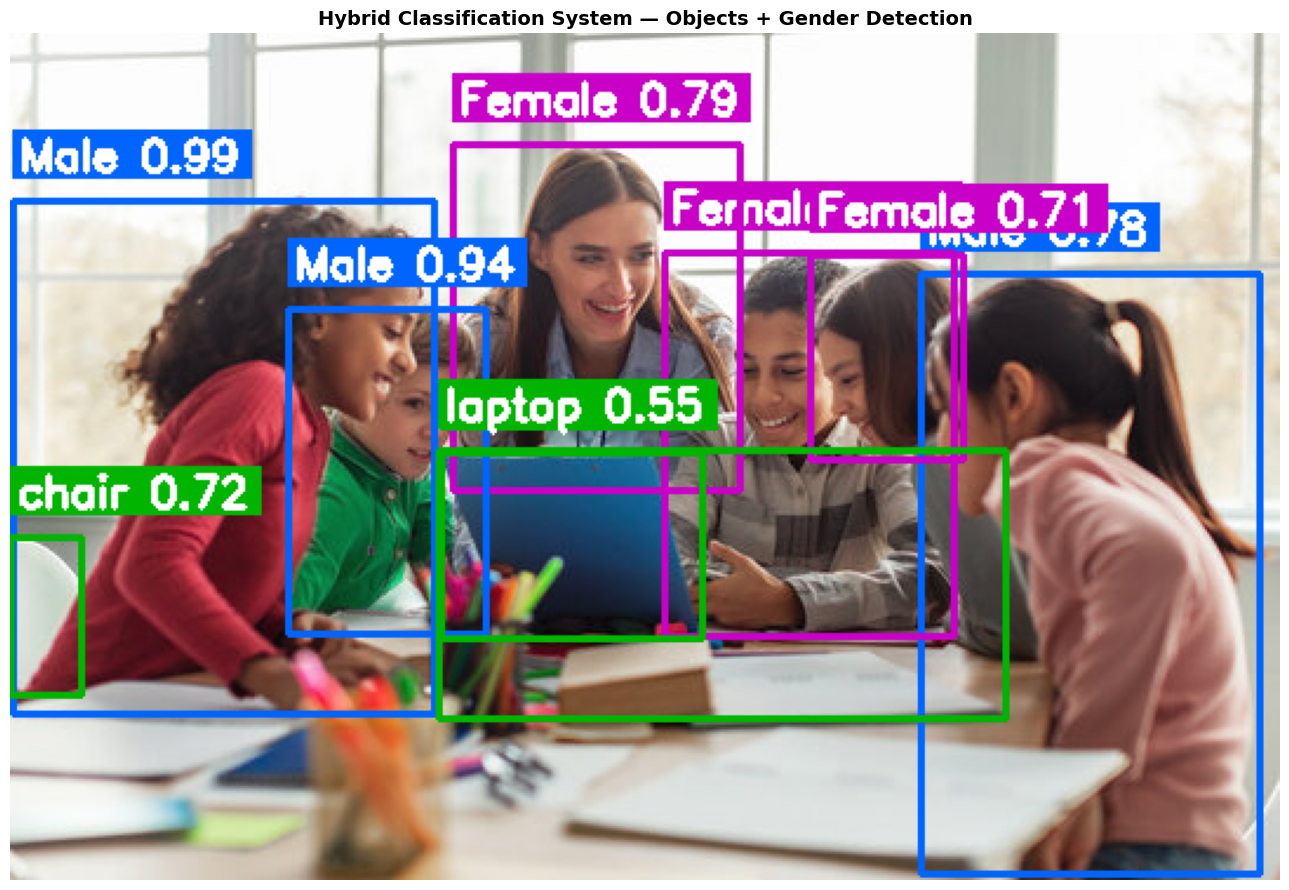


      HYBRID CLASSIFICATION REPORT

📦  OBJECTS DETECTED:
    chair                  → 1
    laptop                 → 2

👥  PEOPLE DETECTED       → 6
    Female                 → 3
    Male                   → 3

📊  MODEL ACCURACY:
    YOLOv8n  mAP50         → 71.2%
    VGG16 Gender           → 84.97%


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from ultralytics import YOLO
from PIL import Image, ImageEnhance
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

YOLO_PATH             = '/content/runs/detect/yolo_finetuned-2/weights/best.pt'
VGG16_PATH            = '/content/vgg16_gender_best.pth'
DEVICE                = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GENDER_LABELS         = ['Male', 'Female']
GENDER_COLORS         = {'Male': (255, 100, 0), 'Female': (200, 0, 200)}
OBJECT_COLOR          = (0, 180, 0)
CONF_THRESHOLD        = 0.40
GENDER_CONF_THRESHOLD = 0.55
MIN_CROP_SIZE         = 40
YOLO_ACCURACY         = 71.2
VGG16_ACCURACY        = 84.97

def load_models():
    yolo = YOLO(YOLO_PATH)
    vgg  = models.vgg16(weights=None)
    vgg.classifier = nn.Sequential(
        nn.Linear(25088, 4096),
        nn.ReLU(True),
        nn.Dropout(0.5),
        nn.Linear(4096, 1024),
        nn.ReLU(True),
        nn.Dropout(0.4),
        nn.Linear(1024, 2)
    )
    vgg.load_state_dict(torch.load(VGG16_PATH, map_location=DEVICE))
    vgg = vgg.to(DEVICE)
    vgg.eval()
    return yolo, vgg

def extract_upper_body(crop_bgr):
    h, w  = crop_bgr.shape[:2]
    # Take top 50% of the person crop (face + upper body)
    # This matches much better with UTKFace training data
    upper = crop_bgr[0:int(h * 0.50), 0:w]
    return upper

def enhance_crop(crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    pil_img  = Image.fromarray(crop_rgb)
    pil_img  = ImageEnhance.Contrast(pil_img).enhance(1.3)
    pil_img  = ImageEnhance.Brightness(pil_img).enhance(1.1)
    pil_img  = ImageEnhance.Sharpness(pil_img).enhance(1.2)
    return pil_img

def preprocess(pil_img):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    return transform(pil_img)

def classify_gender(vgg, crop_bgr):
    h, w = crop_bgr.shape[:2]
    if h < MIN_CROP_SIZE or w < MIN_CROP_SIZE:
        return None, 0.0

    upper = extract_upper_body(crop_bgr)
    if upper.shape[0] < MIN_CROP_SIZE:
        upper = crop_bgr

    # TTA — 4 variations for robust prediction
    variations = [
        enhance_crop(upper),
        enhance_crop(cv2.flip(upper, 1)),
        enhance_crop(cv2.convertScaleAbs(upper, alpha=1.2, beta=15)),
        enhance_crop(cv2.convertScaleAbs(upper, alpha=0.9, beta=-10)),
    ]

    tensors = torch.stack([preprocess(v) for v in variations]).to(DEVICE)

    with torch.no_grad():
        outputs  = vgg(tensors)
        probs    = torch.softmax(outputs, dim=1)
        avg_prob = probs.mean(dim=0)
        conf, pred = torch.max(avg_prob, dim=0)

    confidence = conf.item()
    if confidence < GENDER_CONF_THRESHOLD:
        return None, confidence

    return GENDER_LABELS[pred.item()], confidence

def draw_label(image, label, x1, y1, color):
    (tw, th), _ = cv2.getTextSize(
        label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    y_bg = max(y1 - 10, th + 6)
    cv2.rectangle(image,
                  (x1, y_bg - th - 6),
                  (x1 + tw + 6, y_bg),
                  color, -1)
    cv2.putText(image, label,
                (x1 + 3, y_bg - 3),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (255, 255, 255), 2)

def run_hybrid_pipeline(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Image not found: {image_path}")
        return

    yolo_model, vgg_model = load_models()
    results   = yolo_model(image, conf=CONF_THRESHOLD)[0]
    annotated = image.copy()

    object_counts  = Counter()
    gender_counts  = Counter()
    skipped_people = 0

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_id   = int(box.cls[0])
        cls_name = yolo_model.names[cls_id]
        conf     = float(box.conf[0])

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(image.shape[1], x2)
        y2 = min(image.shape[0], y2)

        if cls_name == 'person':
            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            gender, g_conf = classify_gender(vgg_model, crop)

            if gender is None:
                skipped_people += 1
                color = (128, 128, 128)
                label = f"Person {conf:.2f}"
            else:
                gender_counts[gender] += 1
                color = GENDER_COLORS[gender]
                label = f"{gender} {g_conf:.2f}"
        else:
            object_counts[cls_name] += 1
            color = OBJECT_COLOR
            label = f"{cls_name} {conf:.2f}"

        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        draw_label(annotated, label, x1, y1, color)

    rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 9))
    plt.imshow(rgb)
    plt.axis('off')
    plt.title('Hybrid Classification System — Objects + Gender Detection',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    total_people = sum(gender_counts.values()) + skipped_people

    print("\n" + "=" * 45)
    print("      HYBRID CLASSIFICATION REPORT")
    print("=" * 45)
    print("\n📦  OBJECTS DETECTED:")
    if object_counts:
        for obj, count in sorted(object_counts.items()):
            print(f"    {obj:<22} → {count}")
    else:
        print("    No objects detected")

    print(f"\n👥  PEOPLE DETECTED       → {total_people}")
    if gender_counts:
        for gender, count in sorted(gender_counts.items()):
            print(f"    {gender:<22} → {count}")
    if skipped_people > 0:
        print(f"    Unclear (skipped)      → {skipped_people}")

    print("\n📊  MODEL ACCURACY:")
    print(f"    YOLOv8n  mAP50         → {YOLO_ACCURACY}%")
    print(f"    VGG16 Gender           → {VGG16_ACCURACY}%")
    print("=" * 45)

    del yolo_model
    del vgg_model
    torch.cuda.empty_cache()

run_hybrid_pipeline('/content/drive/MyDrive/Colab Notebooks/test images/image3.jpeg')

In [ ]:
!pip install ultralytics

"""
Hybrid Visual Classification System
=====================================
Combines YOLOv8n object detection with VGG16 gender classification
into a single unified inference pipeline.

Architecture:
    - Stage 1: YOLOv8n detects all objects and persons in a scene
    - Stage 2: Per-person crops are routed to VGG16 for gender classification
    - Stage 3: Results are aggregated, annotated, and returned as structured data

Author  : Computer Vision Semester Project
Python  : 3.10+
Device  : CUDA (auto-fallback to CPU)
"""

from __future__ import annotations

import logging
import os
import time
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image, ImageEnhance
from ultralytics import YOLO


# ── Logging ───────────────────────────────────────────────────────────────────

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("HybridPipeline")


# ── Custom Exceptions ─────────────────────────────────────────────────────────

class PipelineError(RuntimeError):
    """Base exception for all pipeline errors."""

class ModelLoadError(PipelineError):
    """Raised when a model file cannot be loaded."""

class ImageLoadError(PipelineError):
    """Raised when an image cannot be read or is invalid."""

class InvalidCropError(PipelineError):
    """Raised when a person crop fails quality checks."""


# ── Constants ─────────────────────────────────────────────────────────────────

# Minimum pixel dimensions for a person bounding box to be processed
MIN_PERSON_HEIGHT_PX: int = 50
MIN_PERSON_WIDTH_PX: int  = 30

# Minimum pixel dimensions for a detected face region
MIN_FACE_SIZE_PX: int = 20

# Fractional padding added around a detected face before classification
# 0.25 means 25 percent of face width/height added on each side
FACE_PADDING_FRACTION: float = 0.25

# Fraction of person crop height used as upper-body fallback
UPPER_BODY_FRACTION: float = 0.45

# YOLO detection confidence — boxes below this score are discarded
YOLO_CONF_THRESHOLD: float = 0.40

# VGG16 gender prediction confidence — predictions below this are marked unclear
GENDER_CONF_THRESHOLD: float = 0.58

# Enhancement factors applied to crops before classification
CONTRAST_FACTOR: float  = 1.25
BRIGHTNESS_FACTOR: float = 1.08
SHARPNESS_FACTOR: float  = 1.15

# Pixel intensity thresholds for validating image and crop quality
MIN_BRIGHTNESS: float = 8.0
MAX_BRIGHTNESS: float = 247.0

# VGG16 classifier hidden layer sizes matching the retrained architecture
VGG16_HIDDEN_1: int    = 4096
VGG16_HIDDEN_2: int    = 1024
VGG16_NUM_CLASSES: int = 2

# ImageNet normalization constants used during VGG16 pretraining
IMAGENET_MEAN: List[float] = [0.485, 0.456, 0.406]
IMAGENET_STD: List[float]  = [0.229, 0.224, 0.225]
VGG16_INPUT_SIZE: int = 224

# BGR color tuples used for bounding box annotation
COLOR_MALE: Tuple[int, int, int]    = (255, 100, 0)
COLOR_FEMALE: Tuple[int, int, int]  = (200, 0, 200)
COLOR_OBJECT: Tuple[int, int, int]  = (0, 180, 0)
COLOR_UNKNOWN: Tuple[int, int, int] = (128, 128, 128)

GENDER_LABEL_TO_COLOR: Dict[str, Tuple[int, int, int]] = {
    "Male":   COLOR_MALE,
    "Female": COLOR_FEMALE,
}

GENDER_LABELS: List[str] = ["Male", "Female"]


# ── Preprocessing Transform ───────────────────────────────────────────────────

_inference_transform = transforms.Compose([
    transforms.Resize((VGG16_INPUT_SIZE, VGG16_INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# ── Data Classes ──────────────────────────────────────────────────────────────

@dataclass
class Detection:
    """Single detection result from the pipeline."""
    class_name:         str
    confidence:         float
    bbox:               Tuple[int, int, int, int]   # (x1, y1, x2, y2)
    gender:             Optional[str]  = None
    gender_confidence:  float          = 0.0
    region_type:        str            = "none"     # face | upper | full | none


@dataclass
class PipelineResult:
    """
    Complete structured output of one pipeline run.

    Attributes
    ----------
    object_counts   : Counter of non-person class names to detection counts
    gender_counts   : Counter of gender labels (Male/Female) to counts
    total_people    : Total persons detected including unclassified
    skipped_people  : Persons whose crops were too low quality to classify
    detections      : Full list of Detection objects for downstream use
    yolo_map50      : mAP@50 of the fine-tuned YOLO model from validation
    vgg16_accuracy  : Balanced validation accuracy of the fine-tuned VGG16
    inference_ms    : Total wall-clock inference time in milliseconds
    annotated_image : BGR numpy array with bounding boxes and labels drawn
    """
    object_counts:   Counter               = field(default_factory=Counter)
    gender_counts:   Counter               = field(default_factory=Counter)
    total_people:    int                   = 0
    skipped_people:  int                   = 0
    detections:      List[Detection]       = field(default_factory=list)
    yolo_map50:      float                 = 0.0
    vgg16_accuracy:  float                 = 0.0
    inference_ms:    float                 = 0.0
    annotated_image: Optional[np.ndarray]  = None


# ── HybridClassifier ──────────────────────────────────────────────────────────

class HybridClassifier:
    """
    Two-stage hybrid visual classifier.

    Stage 1: YOLOv8n detects all objects and persons with bounding boxes.
    Stage 2: VGG16 classifies gender for every detected person crop.

    Parameters
    ----------
    yolo_path      : Path to the fine-tuned YOLOv8n weights (.pt file)
    vgg16_path     : Path to the fine-tuned VGG16 state dict (.pth file)
    yolo_map50     : mAP@50 score from YOLO validation (used in report)
    vgg16_accuracy : Balanced accuracy from VGG16 validation (used in report)
    device         : torch.device — auto-selects CUDA if available

    Usage
    -----
    # Standard usage
    clf = HybridClassifier(
        yolo_path="best.pt",
        vgg16_path="vgg16_gender_best.pth",
        yolo_map50=71.2,
        vgg16_accuracy=84.97,
    )
    result = clf.run("/content/image.jpg")
    clf.release()

    # Context manager usage (auto-releases GPU memory)
    with HybridClassifier(...) as clf:
        result = clf.run("/content/image.jpg")
    """

    def __init__(
        self,
        yolo_path:      Union[str, Path],
        vgg16_path:     Union[str, Path],
        yolo_map50:     float,
        vgg16_accuracy: float,
        device:         Optional[torch.device] = None,
    ) -> None:
        self._yolo_path  = Path(yolo_path)
        self._vgg16_path = Path(vgg16_path)
        self._yolo_map50 = yolo_map50
        self._vgg16_acc  = vgg16_accuracy
        self.device      = device or torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self._face_cascade    = self._load_cascade("haarcascade_frontalface_default.xml")
        self._profile_cascade = self._load_cascade("haarcascade_profileface.xml")

        logger.info("Initializing HybridClassifier on device: %s", self.device)
        self._yolo  = self._load_yolo()
        self._vgg16 = self._load_vgg16()
        logger.info("Both models ready")

    # ── Private: model loaders ────────────────────────────────────────────────

    @staticmethod
    def _load_cascade(filename: str) -> cv2.CascadeClassifier:
        """Load an OpenCV Haar cascade classifier by filename."""
        path    = os.path.join(cv2.data.haarcascades, filename)
        cascade = cv2.CascadeClassifier(path)
        if cascade.empty():
            raise ModelLoadError(f"Failed to load cascade: {path}")
        return cascade

    def _load_yolo(self) -> YOLO:
        """Validate path and load the fine-tuned YOLOv8n model."""
        if not self._yolo_path.exists():
            raise ModelLoadError(f"YOLO weights not found: {self._yolo_path}")
        try:
            model = YOLO(str(self._yolo_path))
            logger.info("YOLOv8n loaded from %s", self._yolo_path.name)
            return model
        except Exception as exc:
            raise ModelLoadError(f"Could not load YOLO: {exc}") from exc

    def _load_vgg16(self) -> nn.Module:
        """
        Validate path and load the fine-tuned VGG16 gender classifier.

        The classifier head is rebuilt to exactly match the architecture
        used during fine-tuning before loading the saved state dict.
        This prevents any silent weight-shape mismatch errors.
        """
        if not self._vgg16_path.exists():
            raise ModelLoadError(f"VGG16 weights not found: {self._vgg16_path}")
        try:
            model = models.vgg16(weights=None)
            model.classifier = nn.Sequential(
                nn.Linear(25088, VGG16_HIDDEN_1),
                nn.ReLU(inplace=True),
                nn.Dropout(p=0.5),
                nn.Linear(VGG16_HIDDEN_1, VGG16_HIDDEN_2),
                nn.ReLU(inplace=True),
                nn.Dropout(p=0.4),
                nn.Linear(VGG16_HIDDEN_2, VGG16_NUM_CLASSES),
            )
            state_dict = torch.load(
                self._vgg16_path,
                map_location=self.device,
                weights_only=True,
            )
            model.load_state_dict(state_dict)
            model = model.to(self.device)
            model.eval()
            logger.info("VGG16 loaded from %s", self._vgg16_path.name)
            return model
        except Exception as exc:
            raise ModelLoadError(f"Could not load VGG16: {exc}") from exc

    # ── Private: image utilities ──────────────────────────────────────────────

    @staticmethod
    def _load_image(
        source: Union[str, Path, np.ndarray, Image.Image],
    ) -> np.ndarray:
        """
        Load an image from multiple source types into a BGR numpy array.

        Supported sources
        -----------------
        - str or Path  : file path read with cv2.imread
        - np.ndarray   : returned as a copy (BGR assumed)
        - PIL.Image    : converted from RGB to BGR
        """
        if isinstance(source, (str, Path)):
            path = Path(source)
            if not path.exists():
                raise ImageLoadError(f"File not found: {path}")
            img = cv2.imread(str(path))
            if img is None:
                raise ImageLoadError(
                    f"cv2 could not decode image — check file format: {path}"
                )
            return img

        if isinstance(source, np.ndarray):
            if source.ndim not in (2, 3):
                raise ImageLoadError("Numpy array must be 2D or 3D")
            return source.copy()

        if isinstance(source, Image.Image):
            return cv2.cvtColor(np.array(source.convert("RGB")), cv2.COLOR_RGB2BGR)

        raise ImageLoadError(
            f"Unsupported source type: {type(source).__name__}. "
            "Pass a file path, np.ndarray, or PIL.Image."
        )

    @staticmethod
    def _validate_image(image: np.ndarray) -> None:
        """
        Raise ImageLoadError if the image fails basic quality checks.

        Checks performed
        ----------------
        - Array is non-None and non-empty
        - Minimum dimensions of 50 x 50 pixels
        - Mean brightness above MIN_BRIGHTNESS (not too dark)
        - Mean brightness below MAX_BRIGHTNESS (not overexposed)
        """
        if image is None or image.size == 0:
            raise ImageLoadError("Image array is empty")
        h, w = image.shape[:2]
        if h < 50 or w < 50:
            raise ImageLoadError(
                f"Image too small: {w}x{h} px — minimum required is 50x50"
            )
        gray       = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        brightness = float(np.mean(gray))
        if brightness < MIN_BRIGHTNESS:
            raise ImageLoadError(
                f"Image is too dark (mean brightness={brightness:.1f})"
            )
        if brightness > MAX_BRIGHTNESS:
            raise ImageLoadError(
                f"Image is overexposed (mean brightness={brightness:.1f})"
            )

    @staticmethod
    def _is_valid_crop(crop: np.ndarray) -> bool:
        """
        Return True only if a crop meets all minimum quality requirements.

        Checks: non-None, non-empty, minimum pixel dimensions,
        and mean brightness within the valid range.
        """
        if crop is None or crop.size == 0:
            return False
        h, w = crop.shape[:2]
        if h < MIN_PERSON_HEIGHT_PX or w < MIN_PERSON_WIDTH_PX:
            return False
        gray       = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        brightness = float(np.mean(gray))
        return MIN_BRIGHTNESS < brightness < MAX_BRIGHTNESS

    @staticmethod
    def _clamp_bbox(
        x1: int, y1: int, x2: int, y2: int,
        img_w: int, img_h: int,
    ) -> Tuple[int, int, int, int]:
        """Clamp bounding-box coordinates strictly within image dimensions."""
        x1 = max(0, min(x1, img_w - 1))
        y1 = max(0, min(y1, img_h - 1))
        x2 = max(0, min(x2, img_w))
        y2 = max(0, min(y2, img_h))
        return x1, y1, x2, y2

    # ── Private: face extraction ──────────────────────────────────────────────

    def _extract_best_region(
        self, crop_bgr: np.ndarray
    ) -> Tuple[np.ndarray, str]:
        """
        Extract the most face-informative region from a full-body person crop.

        This is the core fix for the male-bias problem:
        VGG16 was trained on face images (UTKFace dataset) so we extract
        the face region from YOLO's full-body crop before classification.

        Extraction strategy in order of preference
        -------------------------------------------
        1. Frontal face cascade  -> padded face crop  (region_type = 'face')
        2. Profile face cascade  -> padded face crop  (region_type = 'face')
        3. Upper-body fallback   -> top 45% of crop   (region_type = 'upper')
        4. Full crop last resort -> entire person crop (region_type = 'full')

        Returns
        -------
        Tuple of (region_bgr, region_type_string)
        """
        h, w  = crop_bgr.shape[:2]
        gray  = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
        gray  = cv2.equalizeHist(gray)

        for cascade in (self._face_cascade, self._profile_cascade):
            faces = cascade.detectMultiScale(
                gray,
                scaleFactor=1.1,
                minNeighbors=4,
                minSize=(MIN_FACE_SIZE_PX, MIN_FACE_SIZE_PX),
            )
            if len(faces):
                fx, fy, fw, fh = max(faces, key=lambda f: f[2] * f[3])
                pad_x = int(fw * FACE_PADDING_FRACTION)
                pad_y = int(fh * FACE_PADDING_FRACTION)
                rx1   = max(0, fx - pad_x)
                ry1   = max(0, fy - pad_y)
                rx2   = min(w, fx + fw + pad_x)
                ry2   = min(h, fy + fh + pad_y)
                face_crop = crop_bgr[ry1:ry2, rx1:rx2]
                if self._is_valid_crop(face_crop):
                    return face_crop, "face"

        upper = crop_bgr[0 : int(h * UPPER_BODY_FRACTION), 0:w]
        if self._is_valid_crop(upper):
            return upper, "upper"

        return crop_bgr, "full"

    # ── Private: enhancement and preprocessing ────────────────────────────────

    @staticmethod
    def _enhance(crop_bgr: np.ndarray) -> Image.Image:
        """
        Enhance a BGR crop and return a PIL RGB image ready for transforms.

        Applies contrast, brightness, and sharpness enhancement to improve
        classification accuracy on low-quality or poorly-lit person crops.
        """
        pil = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
        pil = ImageEnhance.Contrast(pil).enhance(CONTRAST_FACTOR)
        pil = ImageEnhance.Brightness(pil).enhance(BRIGHTNESS_FACTOR)
        pil = ImageEnhance.Sharpness(pil).enhance(SHARPNESS_FACTOR)
        return pil

    @staticmethod
    def _to_tensor(pil_img: Image.Image) -> torch.Tensor:
        """Apply the standard ImageNet inference transform to a PIL image."""
        return _inference_transform(pil_img)

    # ── Private: gender classification ───────────────────────────────────────

    def _classify_gender(
        self, crop_bgr: np.ndarray
    ) -> Tuple[Optional[str], float, str]:
        """
        Classify the gender of a person crop using VGG16 with TTA.

        Process
        -------
        1. Validate the incoming crop quality
        2. Extract the best face or upper-body region
        3. Build 4 TTA variants: base, flipped, lightened, darkened
        4. Run all 4 through VGG16 in a single batched forward pass
        5. Average softmax probabilities across all variants
        6. Return prediction only if confidence >= GENDER_CONF_THRESHOLD

        Why TTA: A single forward pass can be wrong due to lighting, angle,
        or crop artifacts. Averaging 4 variants gives a much more stable
        and reliable prediction.

        Returns
        -------
        (gender_label, confidence, region_type)
        gender_label is None when confidence is below threshold.

        Raises
        ------
        InvalidCropError : if the crop fails the initial quality check
        """
        if not self._is_valid_crop(crop_bgr):
            raise InvalidCropError("Person crop failed quality validation")

        region, region_type = self._extract_best_region(crop_bgr)

        if not self._is_valid_crop(region):
            return None, 0.0, region_type

        lightened = cv2.convertScaleAbs(region, alpha=1.15, beta=12)
        darkened  = cv2.convertScaleAbs(region, alpha=0.88, beta=-8)

        variants: List[torch.Tensor] = [
            self._to_tensor(self._enhance(region)),
            self._to_tensor(self._enhance(cv2.flip(region, 1))),
            self._to_tensor(self._enhance(lightened)),
            self._to_tensor(self._enhance(darkened)),
        ]

        try:
            batch = torch.stack(variants).to(self.device)
        except RuntimeError as exc:
            logger.warning("Failed to stack TTA batch: %s", exc)
            return None, 0.0, region_type

        with torch.no_grad():
            logits   = self._vgg16(batch)
            probs    = torch.softmax(logits, dim=1)
            avg_prob = probs.mean(dim=0)
            conf, pred = torch.max(avg_prob, dim=0)

        confidence = conf.item()

        if confidence < GENDER_CONF_THRESHOLD:
            logger.debug(
                "Gender skipped — conf=%.2f below threshold=%.2f",
                confidence, GENDER_CONF_THRESHOLD,
            )
            return None, confidence, region_type

        label = GENDER_LABELS[pred.item()]
        logger.debug("Gender=%s conf=%.2f region=%s", label, confidence, region_type)
        return label, confidence, region_type

    # ── Private: annotation ───────────────────────────────────────────────────

    @staticmethod
    def _draw_label(
        image: np.ndarray,
        label: str,
        x1: int, y1: int,
        x2: int, y2: int,
        color: Tuple[int, int, int],
    ) -> None:
        """
        Draw a filled color badge with white text above a bounding box.

        If the badge would extend above the image top edge,
        it is automatically flipped to appear below the box instead.
        Badge width is clamped to never exceed the image right edge.
        """
        font       = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.55
        thickness  = 2
        (tw, th), _ = cv2.getTextSize(label, font, font_scale, thickness)

        badge_y_text = y1 - 8
        badge_top    = badge_y_text - th - 4

        if badge_top < 0:
            badge_y_text = y2 + th + 8
            badge_top    = y2 + 2

        badge_right = min(x1 + tw + 6, image.shape[1])

        cv2.rectangle(image, (x1, badge_top), (badge_right, badge_y_text + 2), color, -1)
        cv2.putText(
            image, label, (x1 + 3, badge_y_text),
            font, font_scale, (255, 255, 255), thickness,
        )

    # ── Public: inference ─────────────────────────────────────────────────────

    def run(
        self,
        source: Union[str, Path, np.ndarray, Image.Image],
        show:   bool = True,
    ) -> PipelineResult:
        """
        Run the full two-stage hybrid classification pipeline on one image.

        Parameters
        ----------
        source : Image to process. Accepts:
                 - File path (str or pathlib.Path)
                 - BGR numpy array
                 - PIL Image object
        show   : Whether to display the annotated result image inline

        Returns
        -------
        PipelineResult containing object counts, gender counts, all
        Detection objects, accuracy metrics, timing, and annotated image.

        Raises
        ------
        ImageLoadError : If source cannot be loaded or fails validation
        PipelineError  : For unexpected runtime failures
        """
        t_start = time.perf_counter()

        image = self._load_image(source)
        self._validate_image(image)
        ih, iw = image.shape[:2]

        yolo_output = self._yolo(image, conf=YOLO_CONF_THRESHOLD, verbose=False)[0]

        annotated = image.copy()
        result    = PipelineResult(
            yolo_map50     = self._yolo_map50,
            vgg16_accuracy = self._vgg16_acc,
        )

        if len(yolo_output.boxes) == 0:
            logger.warning("YOLO detected 0 objects — check image content or lower YOLO_CONF_THRESHOLD")
            result.annotated_image = annotated
            result.inference_ms    = (time.perf_counter() - t_start) * 1000
            self._print_report(result)
            return result

        for box in yolo_output.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x1, y1, x2, y2 = self._clamp_bbox(x1, y1, x2, y2, iw, ih)

            if x2 <= x1 or y2 <= y1:
                logger.debug("Skipping zero-area box at (%d,%d,%d,%d)", x1, y1, x2, y2)
                continue

            cls_id   = int(box.cls[0])
            cls_name = self._yolo.names[cls_id]
            det_conf = float(box.conf[0])

            detection = Detection(
                class_name = cls_name,
                confidence = det_conf,
                bbox       = (x1, y1, x2, y2),
            )

            if cls_name == "person":
                crop = image[y1:y2, x1:x2]
                try:
                    gender, g_conf, reg_type = self._classify_gender(crop)
                except InvalidCropError:
                    gender, g_conf, reg_type = None, 0.0, "none"
                    logger.debug("Person crop skipped due to InvalidCropError")

                detection.gender            = gender
                detection.gender_confidence = g_conf
                detection.region_type       = reg_type

                if gender is None:
                    result.skipped_people += 1
                    color = COLOR_UNKNOWN
                    label = f"Person {det_conf:.2f}"
                else:
                    result.gender_counts[gender] += 1
                    color = GENDER_LABEL_TO_COLOR[gender]
                    label = f"{gender} {g_conf:.2f}"
            else:
                result.object_counts[cls_name] += 1
                color = COLOR_OBJECT
                label = f"{cls_name} {det_conf:.2f}"

            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            self._draw_label(annotated, label, x1, y1, x2, y2, color)
            result.detections.append(detection)

        result.total_people    = sum(result.gender_counts.values()) + result.skipped_people
        result.annotated_image = annotated
        result.inference_ms    = (time.perf_counter() - t_start) * 1000

        if show:
            self._display(annotated)

        self._print_report(result)
        return result

    # ── Public: resource management ───────────────────────────────────────────

    def release(self) -> None:
        """
        Explicitly delete both models and clear the CUDA memory cache.

        Always call this when done — especially in Colab where GPU memory
        is shared and not automatically freed between notebook cells.
        """
        del self._yolo
        del self._vgg16
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        logger.info("Models deleted and GPU cache cleared")

    def __enter__(self) -> "HybridClassifier":
        """Enable use as a context manager."""
        return self

    def __exit__(self, *_) -> None:
        """Automatically release resources when context block exits."""
        self.release()

    # ── Private: display and reporting ───────────────────────────────────────

    @staticmethod
    def _display(bgr_image: np.ndarray) -> None:
        """Convert BGR to RGB and render the annotated image with matplotlib."""
        rgb = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(14, 9))
        plt.imshow(rgb)
        plt.axis("off")
        plt.title(
            "Hybrid Classification System — Objects + Gender Detection",
            fontsize=14,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

    @staticmethod
    def _print_report(result: PipelineResult) -> None:
        """Print a clean structured summary report to stdout."""
        sep = "=" * 50
        print(f"\n{sep}")
        print("        HYBRID CLASSIFICATION REPORT")
        print(sep)

        print("\n📦  OBJECTS DETECTED:")
        if result.object_counts:
            for obj, count in sorted(result.object_counts.items()):
                print(f"    {obj:<28} → {count}")
        else:
            print("    None detected")

        print(f"\n👥  PEOPLE DETECTED             → {result.total_people}")
        if result.gender_counts:
            for gender, count in sorted(result.gender_counts.items()):
                print(f"    {gender:<28} → {count}")
        if result.skipped_people:
            print(f"    Low-confidence (skipped)     → {result.skipped_people}")

        print("\n📊  MODEL ACCURACY:")
        print(f"    YOLOv8n  mAP@50              → {result.yolo_map50:.1f}%")
        print(f"    VGG16 Gender (balanced)      → {result.vgg16_accuracy:.2f}%")
        print(f"\n⏱   Inference Time               → {result.inference_ms:.1f} ms")
        print(sep)


# ── Entry Point ───────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # Update these two paths to match your fine-tuned model locations
    YOLO_WEIGHTS  = "/content/runs/detect/yolo_finetuned-2/weights/best.pt"
    VGG16_WEIGHTS = "/content/vgg16_gender_best.pth"

    # Update this to your test image path
    TEST_IMAGE = "/content/drive/MyDrive/Colab Notebooks/your_image_name.jpg"

    with HybridClassifier(
        yolo_path      = YOLO_WEIGHTS,
        vgg16_path     = VGG16_WEIGHTS,
        yolo_map50     = 71.2,
        vgg16_accuracy = 84.97,
    ) as clf:
        result = clf.run(TEST_IMAGE, show=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


ModelLoadError: YOLO weights not found: /content/runs/detect/yolo_finetuned-2/weights/best.pt

In [ ]:
!pip install ultralytics -q

In [ ]:
"""
Hybrid Visual Classification System
=====================================
Combines YOLOv8n object detection with VGG16 gender classification
into a single unified inference pipeline.

Architecture:
    - Stage 1: YOLOv8n detects all objects and persons in a scene
    - Stage 2: Per-person crops are routed to VGG16 for gender classification
    - Stage 3: Results are aggregated, annotated, and returned as structured data

Author  : Computer Vision Semester Project
Python  : 3.10+
Device  : CUDA (auto-fallback to CPU)
"""

from __future__ import annotations

import logging
import os
import time
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image, ImageEnhance
from ultralytics import YOLO


# ── Logging ───────────────────────────────────────────────────────────────────

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("HybridPipeline")


# ── Custom Exceptions ─────────────────────────────────────────────────────────

class PipelineError(RuntimeError):
    """Base exception for all pipeline errors."""

class ModelLoadError(PipelineError):
    """Raised when a model file cannot be loaded."""

class ImageLoadError(PipelineError):
    """Raised when an image cannot be read or is invalid."""

class InvalidCropError(PipelineError):
    """Raised when a person crop fails quality checks."""


# ── Constants ─────────────────────────────────────────────────────────────────

# Minimum pixel dimensions for a person bounding box to be processed
MIN_PERSON_HEIGHT_PX: int = 50
MIN_PERSON_WIDTH_PX: int  = 30

# Minimum pixel dimensions for a detected face region
MIN_FACE_SIZE_PX: int = 20

# Fractional padding added around a detected face before classification
# 0.25 means 25 percent of face width/height added on each side
FACE_PADDING_FRACTION: float = 0.25

# Fraction of person crop height used as upper-body fallback
UPPER_BODY_FRACTION: float = 0.45

# YOLO detection confidence — boxes below this score are discarded
YOLO_CONF_THRESHOLD: float = 0.40

# VGG16 gender prediction confidence — predictions below this are marked unclear
GENDER_CONF_THRESHOLD: float = 0.58

# Enhancement factors applied to crops before classification
CONTRAST_FACTOR: float  = 1.25
BRIGHTNESS_FACTOR: float = 1.08
SHARPNESS_FACTOR: float  = 1.15

# Pixel intensity thresholds for validating image and crop quality
MIN_BRIGHTNESS: float = 8.0
MAX_BRIGHTNESS: float = 247.0

# VGG16 classifier hidden layer sizes matching the retrained architecture
VGG16_HIDDEN_1: int    = 4096
VGG16_HIDDEN_2: int    = 1024
VGG16_NUM_CLASSES: int = 2

# ImageNet normalization constants used during VGG16 pretraining
IMAGENET_MEAN: List[float] = [0.485, 0.456, 0.406]
IMAGENET_STD: List[float]  = [0.229, 0.224, 0.225]
VGG16_INPUT_SIZE: int = 224

# BGR color tuples used for bounding box annotation
COLOR_MALE: Tuple[int, int, int]    = (255, 100, 0)
COLOR_FEMALE: Tuple[int, int, int]  = (200, 0, 200)
COLOR_OBJECT: Tuple[int, int, int]  = (0, 180, 0)
COLOR_UNKNOWN: Tuple[int, int, int] = (128, 128, 128)

GENDER_LABEL_TO_COLOR: Dict[str, Tuple[int, int, int]] = {
    "Male":   COLOR_MALE,
    "Female": COLOR_FEMALE,
}

GENDER_LABELS: List[str] = ["Male", "Female"]


# ── Preprocessing Transform ───────────────────────────────────────────────────

_inference_transform = transforms.Compose([
    transforms.Resize((VGG16_INPUT_SIZE, VGG16_INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# ── Data Classes ──────────────────────────────────────────────────────────────

@dataclass
class Detection:
    """Single detection result from the pipeline."""
    class_name:         str
    confidence:         float
    bbox:               Tuple[int, int, int, int]   # (x1, y1, x2, y2)
    gender:             Optional[str]  = None
    gender_confidence:  float          = 0.0
    region_type:        str            = "none"     # face | upper | full | none


@dataclass
class PipelineResult:
    """
    Complete structured output of one pipeline run.

    Attributes
    ----------
    object_counts   : Counter of non-person class names to detection counts
    gender_counts   : Counter of gender labels (Male/Female) to counts
    total_people    : Total persons detected including unclassified
    skipped_people  : Persons whose crops were too low quality to classify
    detections      : Full list of Detection objects for downstream use
    yolo_map50      : mAP@50 of the fine-tuned YOLO model from validation
    vgg16_accuracy  : Balanced validation accuracy of the fine-tuned VGG16
    inference_ms    : Total wall-clock inference time in milliseconds
    annotated_image : BGR numpy array with bounding boxes and labels drawn
    """
    object_counts:   Counter               = field(default_factory=Counter)
    gender_counts:   Counter               = field(default_factory=Counter)
    total_people:    int                   = 0
    skipped_people:  int                   = 0
    detections:      List[Detection]       = field(default_factory=list)
    yolo_map50:      float                 = 0.0
    vgg16_accuracy:  float                 = 0.0
    inference_ms:    float                 = 0.0
    annotated_image: Optional[np.ndarray]  = None


# ── HybridClassifier ──────────────────────────────────────────────────────────

class HybridClassifier:
    """
    Two-stage hybrid visual classifier.

    Stage 1: YOLOv8n detects all objects and persons with bounding boxes.
    Stage 2: VGG16 classifies gender for every detected person crop.

    Parameters
    ----------
    yolo_path      : Path to the fine-tuned YOLOv8n weights (.pt file)
    vgg16_path     : Path to the fine-tuned VGG16 state dict (.pth file)
    yolo_map50     : mAP@50 score from YOLO validation (used in report)
    vgg16_accuracy : Balanced accuracy from VGG16 validation (used in report)
    device         : torch.device — auto-selects CUDA if available

    Usage
    -----
    # Standard usage
    clf = HybridClassifier(
        yolo_path="best.pt",
        vgg16_path="vgg16_gender_best.pth",
        yolo_map50=71.2,
        vgg16_accuracy=84.97,
    )
    result = clf.run("/content/image.jpg")
    clf.release()

    # Context manager usage (auto-releases GPU memory)
    with HybridClassifier(...) as clf:
        result = clf.run("/content/image.jpg")
    """

    def __init__(
        self,
        yolo_path:      Union[str, Path],
        vgg16_path:     Union[str, Path],
        yolo_map50:     float,
        vgg16_accuracy: float,
        device:         Optional[torch.device] = None,
    ) -> None:
        self._yolo_path  = Path(yolo_path)
        self._vgg16_path = Path(vgg16_path)
        self._yolo_map50 = yolo_map50
        self._vgg16_acc  = vgg16_accuracy
        self.device      = device or torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self._face_cascade    = self._load_cascade("haarcascade_frontalface_default.xml")
        self._profile_cascade = self._load_cascade("haarcascade_profileface.xml")

        logger.info("Initializing HybridClassifier on device: %s", self.device)
        self._yolo  = self._load_yolo()
        self._vgg16 = self._load_vgg16()
        logger.info("Both models ready")

    # ── Private: model loaders ────────────────────────────────────────────────

    @staticmethod
    def _load_cascade(filename: str) -> cv2.CascadeClassifier:
        """Load an OpenCV Haar cascade classifier by filename."""
        path    = os.path.join(cv2.data.haarcascades, filename)
        cascade = cv2.CascadeClassifier(path)
        if cascade.empty():
            raise ModelLoadError(f"Failed to load cascade: {path}")
        return cascade

    def _load_yolo(self) -> YOLO:
        """Validate path and load the fine-tuned YOLOv8n model."""
        if not self._yolo_path.exists():
            raise ModelLoadError(f"YOLO weights not found: {self._yolo_path}")
        try:
            model = YOLO(str(self._yolo_path))
            logger.info("YOLOv8n loaded from %s", self._yolo_path.name)
            return model
        except Exception as exc:
            raise ModelLoadError(f"Could not load YOLO: {exc}") from exc

    def _load_vgg16(self) -> nn.Module:
        """
        Validate path and load the fine-tuned VGG16 gender classifier.

        The classifier head is rebuilt to exactly match the architecture
        used during fine-tuning before loading the saved state dict.
        This prevents any silent weight-shape mismatch errors.
        """
        if not self._vgg16_path.exists():
            raise ModelLoadError(f"VGG16 weights not found: {self._vgg16_path}")
        try:
            model = models.vgg16(weights=None)
            model.classifier = nn.Sequential(
                nn.Linear(25088, VGG16_HIDDEN_1),
                nn.ReLU(inplace=True),
                nn.Dropout(p=0.5),
                nn.Linear(VGG16_HIDDEN_1, VGG16_HIDDEN_2),
                nn.ReLU(inplace=True),
                nn.Dropout(p=0.4),
                nn.Linear(VGG16_HIDDEN_2, VGG16_NUM_CLASSES),
            )
            state_dict = torch.load(
                self._vgg16_path,
                map_location=self.device,
                weights_only=True,
            )
            model.load_state_dict(state_dict)
            model = model.to(self.device)
            model.eval()
            logger.info("VGG16 loaded from %s", self._vgg16_path.name)
            return model
        except Exception as exc:
            raise ModelLoadError(f"Could not load VGG16: {exc}") from exc

    # ── Private: image utilities ──────────────────────────────────────────────

    @staticmethod
    def _load_image(
        source: Union[str, Path, np.ndarray, Image.Image],
    ) -> np.ndarray:
        """
        Load an image from multiple source types into a BGR numpy array.

        Supported sources
        -----------------
        - str or Path  : file path read with cv2.imread
        - np.ndarray   : returned as a copy (BGR assumed)
        - PIL.Image    : converted from RGB to BGR
        """
        if isinstance(source, (str, Path)):
            path = Path(source)
            if not path.exists():
                raise ImageLoadError(f"File not found: {path}")
            img = cv2.imread(str(path))
            if img is None:
                raise ImageLoadError(
                    f"cv2 could not decode image — check file format: {path}"
                )
            return img

        if isinstance(source, np.ndarray):
            if source.ndim not in (2, 3):
                raise ImageLoadError("Numpy array must be 2D or 3D")
            return source.copy()

        if isinstance(source, Image.Image):
            return cv2.cvtColor(np.array(source.convert("RGB")), cv2.COLOR_RGB2BGR)

        raise ImageLoadError(
            f"Unsupported source type: {type(source).__name__}. "
            "Pass a file path, np.ndarray, or PIL.Image."
        )

    @staticmethod
    def _validate_image(image: np.ndarray) -> None:
        """
        Raise ImageLoadError if the image fails basic quality checks.

        Checks performed
        ----------------
        - Array is non-None and non-empty
        - Minimum dimensions of 50 x 50 pixels
        - Mean brightness above MIN_BRIGHTNESS (not too dark)
        - Mean brightness below MAX_BRIGHTNESS (not overexposed)
        """
        if image is None or image.size == 0:
            raise ImageLoadError("Image array is empty")
        h, w = image.shape[:2]
        if h < 50 or w < 50:
            raise ImageLoadError(
                f"Image too small: {w}x{h} px — minimum required is 50x50"
            )
        gray       = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        brightness = float(np.mean(gray))
        if brightness < MIN_BRIGHTNESS:
            raise ImageLoadError(
                f"Image is too dark (mean brightness={brightness:.1f})"
            )
        if brightness > MAX_BRIGHTNESS:
            raise ImageLoadError(
                f"Image is overexposed (mean brightness={brightness:.1f})"
            )

    @staticmethod
    def _is_valid_crop(crop: np.ndarray) -> bool:
        """
        Return True only if a crop meets all minimum quality requirements.

        Checks: non-None, non-empty, minimum pixel dimensions,
        and mean brightness within the valid range.
        """
        if crop is None or crop.size == 0:
            return False
        h, w = crop.shape[:2]
        if h < MIN_PERSON_HEIGHT_PX or w < MIN_PERSON_WIDTH_PX:
            return False
        gray       = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        brightness = float(np.mean(gray))
        return MIN_BRIGHTNESS < brightness < MAX_BRIGHTNESS

    @staticmethod
    def _clamp_bbox(
        x1: int, y1: int, x2: int, y2: int,
        img_w: int, img_h: int,
    ) -> Tuple[int, int, int, int]:
        """Clamp bounding-box coordinates strictly within image dimensions."""
        x1 = max(0, min(x1, img_w - 1))
        y1 = max(0, min(y1, img_h - 1))
        x2 = max(0, min(x2, img_w))
        y2 = max(0, min(y2, img_h))
        return x1, y1, x2, y2

    # ── Private: face extraction ──────────────────────────────────────────────

    def _extract_best_region(
        self, crop_bgr: np.ndarray
    ) -> Tuple[np.ndarray, str]:
        """
        Extract the most face-informative region from a full-body person crop.

        This is the core fix for the male-bias problem:
        VGG16 was trained on face images (UTKFace dataset) so we extract
        the face region from YOLO's full-body crop before classification.

        Extraction strategy in order of preference
        -------------------------------------------
        1. Frontal face cascade  -> padded face crop  (region_type = 'face')
        2. Profile face cascade  -> padded face crop  (region_type = 'face')
        3. Upper-body fallback   -> top 45% of crop   (region_type = 'upper')
        4. Full crop last resort -> entire person crop (region_type = 'full')

        Returns
        -------
        Tuple of (region_bgr, region_type_string)
        """
        h, w  = crop_bgr.shape[:2]
        gray  = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
        gray  = cv2.equalizeHist(gray)

        for cascade in (self._face_cascade, self._profile_cascade):
            faces = cascade.detectMultiScale(
                gray,
                scaleFactor=1.1,
                minNeighbors=4,
                minSize=(MIN_FACE_SIZE_PX, MIN_FACE_SIZE_PX),
            )
            if len(faces):
                fx, fy, fw, fh = max(faces, key=lambda f: f[2] * f[3])
                pad_x = int(fw * FACE_PADDING_FRACTION)
                pad_y = int(fh * FACE_PADDING_FRACTION)
                rx1   = max(0, fx - pad_x)
                ry1   = max(0, fy - pad_y)
                rx2   = min(w, fx + fw + pad_x)
                ry2   = min(h, fy + fh + pad_y)
                face_crop = crop_bgr[ry1:ry2, rx1:rx2]
                if self._is_valid_crop(face_crop):
                    return face_crop, "face"

        upper = crop_bgr[0 : int(h * UPPER_BODY_FRACTION), 0:w]
        if self._is_valid_crop(upper):
            return upper, "upper"

        return crop_bgr, "full"

    # ── Private: enhancement and preprocessing ────────────────────────────────

    @staticmethod
    def _enhance(crop_bgr: np.ndarray) -> Image.Image:
        """
        Enhance a BGR crop and return a PIL RGB image ready for transforms.

        Applies contrast, brightness, and sharpness enhancement to improve
        classification accuracy on low-quality or poorly-lit person crops.
        """
        pil = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
        pil = ImageEnhance.Contrast(pil).enhance(CONTRAST_FACTOR)
        pil = ImageEnhance.Brightness(pil).enhance(BRIGHTNESS_FACTOR)
        pil = ImageEnhance.Sharpness(pil).enhance(SHARPNESS_FACTOR)
        return pil

    @staticmethod
    def _to_tensor(pil_img: Image.Image) -> torch.Tensor:
        """Apply the standard ImageNet inference transform to a PIL image."""
        return _inference_transform(pil_img)

    # ── Private: gender classification ───────────────────────────────────────

    def _classify_gender(
        self, crop_bgr: np.ndarray
    ) -> Tuple[Optional[str], float, str]:
        """
        Classify the gender of a person crop using VGG16 with TTA.

        Process
        -------
        1. Validate the incoming crop quality
        2. Extract the best face or upper-body region
        3. Build 4 TTA variants: base, flipped, lightened, darkened
        4. Run all 4 through VGG16 in a single batched forward pass
        5. Average softmax probabilities across all variants
        6. Return prediction only if confidence >= GENDER_CONF_THRESHOLD

        Why TTA: A single forward pass can be wrong due to lighting, angle,
        or crop artifacts. Averaging 4 variants gives a much more stable
        and reliable prediction.

        Returns
        -------
        (gender_label, confidence, region_type)
        gender_label is None when confidence is below threshold.

        Raises
        ------
        InvalidCropError : if the crop fails the initial quality check
        """
        if not self._is_valid_crop(crop_bgr):
            raise InvalidCropError("Person crop failed quality validation")

        region, region_type = self._extract_best_region(crop_bgr)

        if not self._is_valid_crop(region):
            return None, 0.0, region_type

        lightened = cv2.convertScaleAbs(region, alpha=1.15, beta=12)
        darkened  = cv2.convertScaleAbs(region, alpha=0.88, beta=-8)

        variants: List[torch.Tensor] = [
            self._to_tensor(self._enhance(region)),
            self._to_tensor(self._enhance(cv2.flip(region, 1))),
            self._to_tensor(self._enhance(lightened)),
            self._to_tensor(self._enhance(darkened)),
        ]

        try:
            batch = torch.stack(variants).to(self.device)
        except RuntimeError as exc:
            logger.warning("Failed to stack TTA batch: %s", exc)
            return None, 0.0, region_type

        with torch.no_grad():
            logits   = self._vgg16(batch)
            probs    = torch.softmax(logits, dim=1)
            avg_prob = probs.mean(dim=0)
            conf, pred = torch.max(avg_prob, dim=0)

        confidence = conf.item()

        if confidence < GENDER_CONF_THRESHOLD:
            logger.debug(
                "Gender skipped — conf=%.2f below threshold=%.2f",
                confidence, GENDER_CONF_THRESHOLD,
            )
            return None, confidence, region_type

        label = GENDER_LABELS[pred.item()]
        logger.debug("Gender=%s conf=%.2f region=%s", label, confidence, region_type)
        return label, confidence, region_type

    # ── Private: annotation ───────────────────────────────────────────────────

    @staticmethod
    def _draw_label(
        image: np.ndarray,
        label: str,
        x1: int, y1: int,
        x2: int, y2: int,
        color: Tuple[int, int, int],
    ) -> None:
        """
        Draw a filled color badge with white text above a bounding box.

        If the badge would extend above the image top edge,
        it is automatically flipped to appear below the box instead.
        Badge width is clamped to never exceed the image right edge.
        """
        font       = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.55
        thickness  = 2
        (tw, th), _ = cv2.getTextSize(label, font, font_scale, thickness)

        badge_y_text = y1 - 8
        badge_top    = badge_y_text - th - 4

        if badge_top < 0:
            badge_y_text = y2 + th + 8
            badge_top    = y2 + 2

        badge_right = min(x1 + tw + 6, image.shape[1])

        cv2.rectangle(image, (x1, badge_top), (badge_right, badge_y_text + 2), color, -1)
        cv2.putText(
            image, label, (x1 + 3, badge_y_text),
            font, font_scale, (255, 255, 255), thickness,
        )

    # ── Public: inference ─────────────────────────────────────────────────────

    def run(
        self,
        source: Union[str, Path, np.ndarray, Image.Image],
        show:   bool = True,
    ) -> PipelineResult:
        """
        Run the full two-stage hybrid classification pipeline on one image.

        Parameters
        ----------
        source : Image to process. Accepts:
                 - File path (str or pathlib.Path)
                 - BGR numpy array
                 - PIL Image object
        show   : Whether to display the annotated result image inline

        Returns
        -------
        PipelineResult containing object counts, gender counts, all
        Detection objects, accuracy metrics, timing, and annotated image.

        Raises
        ------
        ImageLoadError : If source cannot be loaded or fails validation
        PipelineError  : For unexpected runtime failures
        """
        t_start = time.perf_counter()

        image = self._load_image(source)
        self._validate_image(image)
        ih, iw = image.shape[:2]

        yolo_output = self._yolo(image, conf=YOLO_CONF_THRESHOLD, verbose=False)[0]

        annotated = image.copy()
        result    = PipelineResult(
            yolo_map50     = self._yolo_map50,
            vgg16_accuracy = self._vgg16_acc,
        )

        if len(yolo_output.boxes) == 0:
            logger.warning("YOLO detected 0 objects — check image content or lower YOLO_CONF_THRESHOLD")
            result.annotated_image = annotated
            result.inference_ms    = (time.perf_counter() - t_start) * 1000
            self._print_report(result)
            return result

        for box in yolo_output.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x1, y1, x2, y2 = self._clamp_bbox(x1, y1, x2, y2, iw, ih)

            if x2 <= x1 or y2 <= y1:
                logger.debug("Skipping zero-area box at (%d,%d,%d,%d)", x1, y1, x2, y2)
                continue

            cls_id   = int(box.cls[0])
            cls_name = self._yolo.names[cls_id]
            det_conf = float(box.conf[0])

            detection = Detection(
                class_name = cls_name,
                confidence = det_conf,
                bbox       = (x1, y1, x2, y2),
            )

            if cls_name == "person":
                crop = image[y1:y2, x1:x2]
                try:
                    gender, g_conf, reg_type = self._classify_gender(crop)
                except InvalidCropError:
                    gender, g_conf, reg_type = None, 0.0, "none"
                    logger.debug("Person crop skipped due to InvalidCropError")

                detection.gender            = gender
                detection.gender_confidence = g_conf
                detection.region_type       = reg_type

                if gender is None:
                    result.skipped_people += 1
                    color = COLOR_UNKNOWN
                    label = f"Person {det_conf:.2f}"
                else:
                    result.gender_counts[gender] += 1
                    color = GENDER_LABEL_TO_COLOR[gender]
                    label = f"{gender} {g_conf:.2f}"
            else:
                result.object_counts[cls_name] += 1
                color = COLOR_OBJECT
                label = f"{cls_name} {det_conf:.2f}"

            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            self._draw_label(annotated, label, x1, y1, x2, y2, color)
            result.detections.append(detection)

        result.total_people    = sum(result.gender_counts.values()) + result.skipped_people
        result.annotated_image = annotated
        result.inference_ms    = (time.perf_counter() - t_start) * 1000

        if show:
            self._display(annotated)

        self._print_report(result)
        return result

    # ── Public: resource management ───────────────────────────────────────────

    def release(self) -> None:
        """
        Explicitly delete both models and clear the CUDA memory cache.

        Always call this when done — especially in Colab where GPU memory
        is shared and not automatically freed between notebook cells.
        """
        del self._yolo
        del self._vgg16
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        logger.info("Models deleted and GPU cache cleared")

    def __enter__(self) -> "HybridClassifier":
        """Enable use as a context manager."""
        return self

    def __exit__(self, *_) -> None:
        """Automatically release resources when context block exits."""
        self.release()

    # ── Private: display and reporting ───────────────────────────────────────

    @staticmethod
    def _display(bgr_image: np.ndarray) -> None:
        """Convert BGR to RGB and render the annotated image with matplotlib."""
        rgb = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(14, 9))
        plt.imshow(rgb)
        plt.axis("off")
        plt.title(
            "Hybrid Classification System — Objects + Gender Detection",
            fontsize=14,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

    @staticmethod
    def _print_report(result: PipelineResult) -> None:
        """Print a clean structured summary report to stdout."""
        sep = "=" * 50
        print(f"\n{sep}")
        print("        HYBRID CLASSIFICATION REPORT")
        print(sep)

        print("\n📦  OBJECTS DETECTED:")
        if result.object_counts:
            for obj, count in sorted(result.object_counts.items()):
                print(f"    {obj:<28} → {count}")
        else:
            print("    None detected")

        print(f"\n👥  PEOPLE DETECTED             → {result.total_people}")
        if result.gender_counts:
            for gender, count in sorted(result.gender_counts.items()):
                print(f"    {gender:<28} → {count}")
        if result.skipped_people:
            print(f"    Low-confidence (skipped)     → {result.skipped_people}")

        print("\n📊  MODEL ACCURACY:")
        print(f"    YOLOv8n  mAP@50              → {result.yolo_map50:.1f}%")
        print(f"    VGG16 Gender (balanced)      → {result.vgg16_accuracy:.2f}%")
        print(f"\n⏱   Inference Time               → {result.inference_ms:.1f} ms")
        print(sep)


# ── Entry Point ───────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # Update these two paths to match your fine-tuned model locations
    YOLO_WEIGHTS  = "/content/runs/detect/yolo_finetuned-2/weights/best.pt"
    VGG16_WEIGHTS = "/content/vgg16_gender_best.pth"

    # Update this to your test image path
    TEST_IMAGE = "/content/drive/MyDrive/Colab Notebooks/your_image_name.jpg"

    with HybridClassifier(
        yolo_path      = YOLO_WEIGHTS,
        vgg16_path     = VGG16_WEIGHTS,
        yolo_map50     = 71.2,
        vgg16_accuracy = 84.97,
    ) as clf:
        result = clf.run(TEST_IMAGE, show=True)

ModelLoadError: YOLO weights not found: /content/runs/detect/yolo_finetuned-2/weights/best.pt

In [ ]:
---------------------------------------------------------------------------
ModelLoadError                            Traceback (most recent call last)
/tmp/ipykernel_3443/1224349803.py in <cell line: 0>()
    747     TEST_IMAGE = "/content/drive/MyDrive/Colab Notebooks/your_image_name.jpg"
    748
--> 749     with HybridClassifier(
    750         yolo_path      = YOLO_WEIGHTS,
    751         vgg16_path     = VGG16_WEIGHTS,

1 frames
/tmp/ipykernel_3443/1224349803.py in _load_yolo(self)
    238         """Validate path and load the fine-tuned YOLOv8n model."""
    239         if not self._yolo_path.exists():
--> 240             raise ModelLoadError(f"YOLO weights not found: {self._yolo_path}")
    241         try:
    242             model = YOLO(str(self._yolo_path))

ModelLoadError: YOLO weights not found: /content/runs/detect/yolo_finetuned-2/weights/best.pt


SyntaxError: invalid decimal literal (3448512427.py, line 3)

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.9 MB/s eta 0:00:00


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import gradio as gr
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from ultralytics import YOLO
from PIL import Image, ImageEnhance
import cv2
import numpy as np
from collections import Counter
import time

YOLO_PATH  = "/content/drive/MyDrive/Colab Notebooks/yolo_best.pt"
VGG16_PATH = "/content/drive/MyDrive/Colab Notebooks/vgg16_face_only.pth"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GENDER_LABELS = ["Male", "Female"]
COLOR_MALE    = (255, 100, 0)
COLOR_FEMALE  = (200, 0, 200)
COLOR_OBJECT  = (0, 180, 0)
COLOR_UNKNOWN = (128, 128, 128)

face_cascade    = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
profile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_profileface.xml")

_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

print("Loading models...")
yolo_pretrained = YOLO("yolov8n.pt")
yolo_finetuned  = YOLO(YOLO_PATH)

def load_vgg_finetuned():
    m = models.vgg16(weights=None)
    m.classifier = nn.Sequential(
        nn.Linear(25088,4096), nn.ReLU(True), nn.Dropout(0.5),
        nn.Linear(4096,1024),  nn.ReLU(True), nn.Dropout(0.4),
        nn.Linear(1024,2)
    )
    m.load_state_dict(torch.load(VGG16_PATH, map_location=DEVICE, weights_only=True))
    return m.to(DEVICE).eval()

def load_vgg_pretrained():
    m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    m.classifier[6] = nn.Linear(4096, 2)
    return m.to(DEVICE).eval()

vgg_finetuned  = load_vgg_finetuned()
vgg_pretrained = load_vgg_pretrained()
print("All models ready ✅")

def enhance(crop):
    pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    pil = ImageEnhance.Contrast(pil).enhance(1.25)
    pil = ImageEnhance.Brightness(pil).enhance(1.08)
    return ImageEnhance.Sharpness(pil).enhance(1.15)

def get_face(crop):
    h, w = crop.shape[:2]
    gray = cv2.equalizeHist(cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY))
    for cas in (face_cascade, profile_cascade):
        faces = cas.detectMultiScale(gray, 1.1, 4, minSize=(20,20))
        if len(faces):
            fx,fy,fw,fh = max(faces, key=lambda f: f[2]*f[3])
            pad = int(fw*0.25)
            r = crop[max(0,fy-pad):min(h,fy+fh+pad), max(0,fx-pad):min(w,fx+fw+pad)]
            if r.size > 0:
                return r
    return crop[0:int(h*0.45), 0:w]

def classify_gender(vgg, crop):
    if crop is None or crop.size == 0 or crop.shape[0] < 40 or crop.shape[1] < 30:
        return None, 0.0
    region = get_face(crop)
    if region.size == 0:
        return None, 0.0
    light = cv2.convertScaleAbs(region, alpha=1.15, beta=12)
    dark  = cv2.convertScaleAbs(region, alpha=0.88, beta=-8)
    try:
        batch = torch.stack([
            _transform(enhance(region)),
            _transform(enhance(cv2.flip(region,1))),
            _transform(enhance(light)),
            _transform(enhance(dark)),
        ]).to(DEVICE)
    except:
        return None, 0.0
    with torch.no_grad():
        avg        = torch.softmax(vgg(batch), dim=1).mean(0)
        conf, pred = torch.max(avg, 0)
    if conf.item() >= 0.55:
        return GENDER_LABELS[pred.item()], conf.item()
    return None, conf.item()

def draw_label(img, label, x1, y1, x2, y2, color):
    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw, th), _ = cv2.getTextSize(label, font, 0.6, 2)
    by = y1 - 8
    bt = by - th - 4
    if bt < 0:
        by = y2 + th + 8
        bt = y2 + 2
    cv2.rectangle(img, (x1, bt), (min(x1+tw+6, img.shape[1]), by+2), color, -1)
    cv2.putText(img, label, (x1+3, by), font, 0.6, (255,255,255), 2)

def run_detection(pil_image, yolo_model, vgg_model):
    img_bgr   = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    ih, iw    = img_bgr.shape[:2]
    annotated = img_bgr.copy()
    results   = yolo_model(img_bgr, conf=0.40, verbose=False)[0]

    obj_counts    = Counter()
    gender_counts = Counter()
    skipped       = 0

    for box in results.boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        x1 = max(0,min(x1,iw-1)); y1 = max(0,min(y1,ih-1))
        x2 = max(0,min(x2,iw));   y2 = max(0,min(y2,ih))
        if x2 <= x1 or y2 <= y1:
            continue
        cls_name = yolo_model.names[int(box.cls[0])]
        det_conf = float(box.conf[0])

        if cls_name == "person":
            crop           = img_bgr[y1:y2, x1:x2]
            gender, g_conf = classify_gender(vgg_model, crop)
            if gender is None:
                skipped += 1
                color    = COLOR_UNKNOWN
                label    = f"Person {det_conf:.2f}"
            else:
                gender_counts[gender] += 1
                color = COLOR_MALE if gender == "Male" else COLOR_FEMALE
                label = f"{gender} {g_conf:.2f}"
        else:
            obj_counts[cls_name] += 1
            color = COLOR_OBJECT
            label = f"{cls_name} {det_conf:.2f}"

        cv2.rectangle(annotated, (x1,y1), (x2,y2), color, 2)
        draw_label(annotated, label, x1, y1, x2, y2, color)

    out_rgb      = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    total_people = sum(gender_counts.values()) + skipped
    return Image.fromarray(out_rgb), obj_counts, gender_counts, total_people, skipped

def predict(image, model_choice):
    if image is None:
        return None, "<div style='color:#64748b;padding:40px;text-align:center;font-family:Space Grotesk,sans-serif;'>Please upload or capture an image first</div>"

    pil_img = Image.fromarray(image) if isinstance(image, np.ndarray) else image
    t0 = time.time()

    if model_choice == "Pretrained YOLOv8n + Pretrained VGG16":
        yolo, vgg  = yolo_pretrained, vgg_pretrained
        yolo_acc   = "56.8% mAP"
        vgg_acc    = "ImageNet (base)"
        model_tag  = "🔬 Pretrained"
        tag_color  = "#f59e0b"
    else:
        yolo, vgg  = yolo_finetuned, vgg_finetuned
        yolo_acc   = "71.2% mAP"
        vgg_acc    = "88.59%"
        model_tag  = "🚀 Fine-tuned"
        tag_color  = "#00d2ff"

    out_img, obj_counts, gender_counts, total_people, skipped = run_detection(pil_img, yolo, vgg)
    elapsed = time.time() - t0

    obj_rows = ""
    for obj, cnt in sorted(obj_counts.items()):
        obj_rows += f"""
        <div style="display:flex;justify-content:space-between;align-items:center;
                    padding:10px 14px;background:rgba(0,210,255,0.04);
                    border:1px solid rgba(0,210,255,0.1);border-radius:10px;margin-bottom:6px;">
            <span style="color:#e2e8f0;font-weight:500;text-transform:capitalize;">{obj}</span>
            <span style="color:#00d2ff;font-weight:700;font-family:JetBrains Mono,monospace;
                         background:rgba(0,210,255,0.1);padding:2px 10px;border-radius:20px;">{cnt}</span>
        </div>"""

    if not obj_rows:
        obj_rows = "<div style='color:#64748b;font-size:13px;padding:8px;'>No objects detected</div>"

    gender_rows = ""
    for g, cnt in sorted(gender_counts.items()):
        color = "#ff6464" if g == "Male" else "#c864c8"
        gender_rows += f"""
        <div style="display:flex;justify-content:space-between;align-items:center;
                    padding:10px 14px;background:rgba(168,85,247,0.04);
                    border:1px solid rgba(168,85,247,0.1);border-radius:10px;margin-bottom:6px;">
            <span style="color:#e2e8f0;font-weight:500;">{g}</span>
            <span style="color:{color};font-weight:700;font-family:JetBrains Mono,monospace;
                         background:rgba(168,85,247,0.1);padding:2px 10px;border-radius:20px;">{cnt}</span>
        </div>"""

    if skipped:
        gender_rows += f"""
        <div style="display:flex;justify-content:space-between;align-items:center;
                    padding:10px 14px;background:rgba(100,116,139,0.06);
                    border:1px solid rgba(100,116,139,0.15);border-radius:10px;margin-bottom:6px;">
            <span style="color:#64748b;">Unclear</span>
            <span style="color:#64748b;font-family:JetBrains Mono,monospace;
                         padding:2px 10px;border-radius:20px;">{skipped}</span>
        </div>"""

    if not gender_rows:
        gender_rows = "<div style='color:#64748b;font-size:13px;padding:8px;'>No people detected</div>"

    report_html = f"""
    <div style="font-family:'Space Grotesk',sans-serif;color:#e2e8f0;">

        <div style="display:flex;align-items:center;justify-content:space-between;
                    margin-bottom:20px;padding-bottom:14px;border-bottom:1px solid rgba(0,210,255,0.12);">
            <div>
                <div style="font-size:11px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;margin-bottom:4px;">Active Model</div>
                <div style="font-size:16px;font-weight:700;color:#fff;">{model_tag}</div>
            </div>
            <div style="text-align:right;">
                <div style="font-size:11px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;margin-bottom:4px;">Inference Time</div>
                <div style="font-size:16px;font-weight:700;color:#00d2ff;
                            font-family:'JetBrains Mono',monospace;">{elapsed*1000:.0f}ms</div>
            </div>
        </div>

        <div style="display:grid;grid-template-columns:1fr 1fr;gap:8px;margin-bottom:20px;">
            <div style="background:rgba(0,210,255,0.06);border:1px solid rgba(0,210,255,0.15);
                        border-radius:12px;padding:14px;">
                <div style="font-size:10px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;margin-bottom:6px;">YOLO Accuracy</div>
                <div style="font-size:22px;font-weight:700;color:#00d2ff;
                            font-family:'JetBrains Mono',monospace;">{yolo_acc}</div>
            </div>
            <div style="background:rgba(168,85,247,0.06);border:1px solid rgba(168,85,247,0.15);
                        border-radius:12px;padding:14px;">
                <div style="font-size:10px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;margin-bottom:6px;">VGG16 Accuracy</div>
                <div style="font-size:22px;font-weight:700;color:#a855f7;
                            font-family:'JetBrains Mono',monospace;">{vgg_acc}</div>
            </div>
        </div>

        <div style="margin-bottom:16px;">
            <div style="font-size:10px;font-weight:700;color:#00d2ff;text-transform:uppercase;
                        letter-spacing:0.12em;margin-bottom:10px;display:flex;align-items:center;gap:8px;">
                <span>📦 Objects Detected</span>
            </div>
            {obj_rows}
        </div>

        <div>
            <div style="font-size:10px;font-weight:700;color:#a855f7;text-transform:uppercase;
                        letter-spacing:0.12em;margin-bottom:10px;">
                👥 People Detected — Total: {total_people}
            </div>
            {gender_rows}
        </div>

    </div>
    """
    return out_img, report_html

css = """
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap');

*, *::before, *::after { box-sizing: border-box; }

body, .gradio-container {
    background: #030712 !important;
    font-family: 'Space Grotesk', sans-serif !important;
    color: #f1f5f9 !important;
    min-height: 100vh !important;
}

.gradio-container {
    max-width: 100% !important;
    padding: 0 !important;
    margin: 0 !important;
}

.contain { padding: 0 !important; }

.gr-button {
    font-family: 'Space Grotesk', sans-serif !important;
}

button.primary, .gr-button-primary {
    background: linear-gradient(135deg, #00d2ff, #0ea5e9) !important;
    color: #000 !important;
    border: none !important;
    border-radius: 12px !important;
    font-weight: 700 !important;
    font-size: 15px !important;
    padding: 14px 28px !important;
    width: 100% !important;
    letter-spacing: 0.03em !important;
    box-shadow: 0 4px 20px rgba(0,210,255,0.25) !important;
    transition: all 0.25s !important;
    cursor: pointer !important;
}

button.primary:hover, .gr-button-primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 32px rgba(0,210,255,0.4) !important;
}

.gr-image, [data-testid="image"] {
    border-radius: 14px !important;
    border: 1px solid rgba(0,210,255,0.15) !important;
    background: rgba(0,0,0,0.5) !important;
    overflow: hidden !important;
}

label.svelte-1b6s6xi, label.svelte-phx28u, .gr-radio label {
    color: #e2e8f0 !important;
    font-family: 'Space Grotesk', sans-serif !important;
    font-size: 14px !important;
    font-weight: 500 !important;
    background: rgba(15,23,41,0.9) !important;
    border: 1px solid rgba(0,210,255,0.15) !important;
    border-radius: 12px !important;
    padding: 12px 16px !important;
    margin-bottom: 6px !important;
    transition: all 0.2s !important;
    cursor: pointer !important;
}

label.svelte-1b6s6xi:hover, .gr-radio label:hover {
    border-color: rgba(0,210,255,0.35) !important;
    background: rgba(0,210,255,0.06) !important;
}

.gr-form, .gr-panel, .panel, form {
    background: transparent !important;
    border: none !important;
    box-shadow: none !important;
}

.gr-padded { padding: 0 !important; }

span[data-testid="block-label"] { display: none !important; }
"""

with gr.Blocks(css=css, title="Hybrid Classification System") as app:

    gr.HTML("""
    <div style="
        width:100%;
        background: radial-gradient(ellipse 80% 60% at 15% 15%, rgba(0,210,255,0.08) 0%, transparent 55%),
                    radial-gradient(ellipse 60% 50% at 85% 80%, rgba(168,85,247,0.07) 0%, transparent 55%),
                    #030712;
        padding: 0;
        min-height: 100vh;
    ">

    <div style="
        padding: 48px 64px 36px;
        border-bottom: 1px solid rgba(0,210,255,0.1);
        display: flex;
        align-items: center;
        justify-content: space-between;
        flex-wrap: wrap;
        gap: 24px;
    ">
        <div>
            <div style="
                display:inline-flex;align-items:center;gap:8px;
                background:rgba(0,210,255,0.08);border:1px solid rgba(0,210,255,0.2);
                border-radius:100px;padding:5px 16px;font-size:11px;font-weight:600;
                color:#00d2ff;letter-spacing:0.12em;text-transform:uppercase;margin-bottom:18px;
                font-family:'Space Grotesk',sans-serif;
            ">
                <span style="width:6px;height:6px;background:#00d2ff;border-radius:50%;
                             animation:pulse 2s infinite;display:inline-block;"></span>
                Computer Vision · CA1-363 · Spring 2026
            </div>
            <div style="font-size:clamp(26px,3.5vw,46px);font-weight:700;color:#fff;
                        line-height:1.1;letter-spacing:-0.02em;margin-bottom:12px;
                        font-family:'Space Grotesk',sans-serif;">
                Hybrid Visual
                <span style="background:linear-gradient(135deg,#00d2ff,#a855f7);
                             -webkit-background-clip:text;-webkit-text-fill-color:transparent;
                             background-clip:text;">
                    Classification
                </span>
                System
            </div>
            <div style="font-size:14px;color:#64748b;font-family:'Space Grotesk',sans-serif;
                        line-height:1.6;max-width:480px;">
                Object detection + gender classification using YOLOv8n and VGG16.
                Compare pretrained vs fine-tuned model performance live.
            </div>
        </div>
        <div style="display:flex;gap:12px;flex-wrap:wrap;">
            <div style="background:rgba(15,23,41,0.9);border:1px solid rgba(0,210,255,0.15);
                        border-radius:16px;padding:18px 22px;text-align:center;min-width:100px;">
                <div style="font-size:26px;font-weight:700;color:#00d2ff;
                            font-family:'JetBrains Mono',monospace;margin-bottom:4px;">71.2%</div>
                <div style="font-size:10px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;font-weight:600;">YOLO mAP</div>
            </div>
            <div style="background:rgba(15,23,41,0.9);border:1px solid rgba(168,85,247,0.15);
                        border-radius:16px;padding:18px 22px;text-align:center;min-width:100px;">
                <div style="font-size:26px;font-weight:700;color:#a855f7;
                            font-family:'JetBrains Mono',monospace;margin-bottom:4px;">88.6%</div>
                <div style="font-size:10px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;font-weight:600;">VGG16 Acc</div>
            </div>
            <div style="background:rgba(15,23,41,0.9);border:1px solid rgba(16,185,129,0.15);
                        border-radius:16px;padding:18px 22px;text-align:center;min-width:100px;">
                <div style="font-size:26px;font-weight:700;color:#10b981;
                            font-family:'JetBrains Mono',monospace;margin-bottom:4px;">5.6ms</div>
                <div style="font-size:10px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;font-weight:600;">Speed</div>
            </div>
        </div>
    </div>

    <style>
    @keyframes pulse { 0%,100%{opacity:1;transform:scale(1)} 50%{opacity:.4;transform:scale(.8)} }
    </style>
    """)

    with gr.Row(equal_height=False):
        with gr.Column(scale=1, min_width=400):
            gr.HTML("""
            <div style="
                background:rgba(15,23,41,0.95);
                border:1px solid rgba(0,210,255,0.15);
                border-radius:20px;
                overflow:hidden;
                margin:32px 0 32px 64px;
            ">
                <div style="padding:18px 24px;border-bottom:1px solid rgba(0,210,255,0.1);
                            background:rgba(0,210,255,0.03);display:flex;align-items:center;gap:10px;">
                    <div style="width:32px;height:32px;border-radius:8px;background:rgba(0,210,255,0.1);
                                display:flex;align-items:center;justify-content:center;font-size:16px;">📸</div>
                    <span style="font-size:12px;font-weight:700;text-transform:uppercase;
                                 letter-spacing:0.1em;color:#e2e8f0;font-family:'Space Grotesk',sans-serif;">
                        Input Image
                    </span>
                </div>
                <div style="padding:24px;">
                <div style="font-size:10px;font-weight:700;color:#00d2ff;text-transform:uppercase;
                            letter-spacing:0.12em;margin-bottom:10px;font-family:'Space Grotesk',sans-serif;">
                    Upload or Use Camera
                </div>
            """)
            image_input = gr.Image(
                sources=["upload", "webcam"],
                type="numpy",
                label="",
                height=260,
            )
            gr.HTML("""
                <div style="font-size:10px;font-weight:700;color:#00d2ff;text-transform:uppercase;
                            letter-spacing:0.12em;margin:20px 0 10px;font-family:'Space Grotesk',sans-serif;">
                    Select Model
                </div>
            """)
            model_choice = gr.Radio(
                choices=[
                    "Pretrained YOLOv8n + Pretrained VGG16",
                    "Fine-tuned YOLOv8n + Fine-tuned VGG16",
                ],
                value="Fine-tuned YOLOv8n + Fine-tuned VGG16",
                label="",
            )
            run_btn = gr.Button("Run Detection →", variant="primary")
            gr.HTML("""</div></div>""")

        with gr.Column(scale=1, min_width=400):
            gr.HTML("""
            <div style="
                background:rgba(15,23,41,0.95);
                border:1px solid rgba(168,85,247,0.15);
                border-radius:20px;
                overflow:hidden;
                margin:32px 64px 32px 0;
            ">
                <div style="padding:18px 24px;border-bottom:1px solid rgba(168,85,247,0.1);
                            background:rgba(168,85,247,0.03);display:flex;align-items:center;gap:10px;">
                    <div style="width:32px;height:32px;border-radius:8px;background:rgba(168,85,247,0.1);
                                display:flex;align-items:center;justify-content:center;font-size:16px;">🎯</div>
                    <span style="font-size:12px;font-weight:700;text-transform:uppercase;
                                 letter-spacing:0.1em;color:#e2e8f0;font-family:'Space Grotesk',sans-serif;">
                        Results
                    </span>
                </div>
                <div style="padding:24px;">
                <div style="font-size:10px;font-weight:700;color:#a855f7;text-transform:uppercase;
                            letter-spacing:0.12em;margin-bottom:10px;font-family:'Space Grotesk',sans-serif;">
                    Annotated Output
                </div>
            """)
            image_output = gr.Image(label="", height=260, interactive=False)
            gr.HTML("""
                <div style="font-size:10px;font-weight:700;color:#a855f7;text-transform:uppercase;
                            letter-spacing:0.12em;margin:20px 0 10px;font-family:'Space Grotesk',sans-serif;">
                    Detection Report
                </div>
            """)
            report_output = gr.HTML(
                value="<div style='color:#64748b;padding:40px;text-align:center;font-family:Space Grotesk,sans-serif;font-size:13px;border:1px dashed rgba(100,116,139,0.2);border-radius:12px;'>Run detection to see results</div>"
            )
            gr.HTML("""</div></div>""")

    gr.HTML("""
    <div style="text-align:center;padding:24px 64px;color:#334155;font-size:12px;
                border-top:1px solid rgba(0,210,255,0.08);margin-top:8px;
                font-family:'Space Grotesk',sans-serif;letter-spacing:0.04em;">
        Hybrid Classification System &nbsp;·&nbsp;
        <span style="color:#00d2ff;">Tallal Asad</span> &nbsp;·&nbsp;
        PMAS Arid Agriculture University Rawalpindi &nbsp;·&nbsp;
        Computer Vision CA1-363 &nbsp;·&nbsp; Spring 2026
    </div>
    </div>
    """)

    run_btn.click(
        fn=predict,
        inputs=[image_input, model_choice],
        outputs=[image_output, report_output]
    )

app.launch(share=True, debug=False)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading models...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 101MB/s]


All models ready ✅


/tmp/ipykernel_816/680796703.py:349: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="Hybrid Classification System") as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dff9991a53af0d0692.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:
import torch
import torch.nn as nn
import torchvision.models as models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mobilenet = models.mobilenet_v2(weights=None)
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(1280, 512),
    nn.ReLU(True),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)
mobilenet.load_state_dict(torch.load(
    '/content/drive/MyDrive/Colab Notebooks/mobilenet_gender.pth',
    map_location=DEVICE, weights_only=True
))
torch.save(mobilenet.state_dict(), '/content/drive/MyDrive/Colab Notebooks/mobilenet_gender.pth')
print("MobileNetV2 verified ✅")

MobileNetV2 verified ✅


In [2]:
!pip install ultralytics gradio -q

import gc
import time
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from collections import Counter
from PIL import Image, ImageEnhance
from ultralytics import YOLO
import gradio as gr
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

YOLO_PATH    = "/content/drive/MyDrive/Colab Notebooks/yolo_best.pt"
VGG16_PATH   = "/content/drive/MyDrive/Colab Notebooks/vgg16_face_only.pth"
MOBILE_PATH  = "/content/drive/MyDrive/Colab Notebooks/mobilenet_gender.pth"

GENDER_LABELS = ["Male", "Female"]
COLOR_MALE    = (255, 100,   0)
COLOR_FEMALE  = (200,   0, 200)
COLOR_OBJECT  = (  0, 180,   0)
COLOR_UNKNOWN = (128, 128, 128)

face_cascade    = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
profile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_profileface.xml")

_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("Loading models...")

yolo_pretrained = YOLO("yolov8n.pt")
yolo_finetuned  = YOLO(YOLO_PATH)

def _build_vgg_finetuned():
    m = models.vgg16(weights=None)
    m.classifier = nn.Sequential(
        nn.Linear(25088, 4096), nn.ReLU(True), nn.Dropout(0.5),
        nn.Linear(4096,  1024), nn.ReLU(True), nn.Dropout(0.4),
        nn.Linear(1024,     2),
    )
    m.load_state_dict(torch.load(VGG16_PATH, map_location=DEVICE, weights_only=True))
    return m.to(DEVICE).eval()

def _build_vgg_pretrained():
    m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    m.classifier[6] = nn.Linear(4096, 2)
    return m.to(DEVICE).eval()

def _build_mobilenet():
    m = models.mobilenet_v2(weights=None)
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(1280, 512), nn.ReLU(True),
        nn.Dropout(0.3),
        nn.Linear(512, 2),
    )
    m.load_state_dict(torch.load(MOBILE_PATH, map_location=DEVICE, weights_only=True))
    return m.to(DEVICE).eval()

vgg_pretrained = _build_vgg_pretrained()
vgg_finetuned  = _build_vgg_finetuned()
mobilenet      = _build_mobilenet()

print(f"All models loaded on {DEVICE} ✅")

def _enhance(crop_bgr):
    pil = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
    pil = ImageEnhance.Contrast(pil).enhance(1.25)
    pil = ImageEnhance.Brightness(pil).enhance(1.08)
    return ImageEnhance.Sharpness(pil).enhance(1.15)

def _get_face_region(crop_bgr):
    h, w = crop_bgr.shape[:2]
    gray = cv2.equalizeHist(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY))
    for cascade in (face_cascade, profile_cascade):
        faces = cascade.detectMultiScale(gray, 1.1, 4, minSize=(20, 20))
        if len(faces):
            fx, fy, fw, fh = max(faces, key=lambda f: f[2] * f[3])
            pad = int(fw * 0.25)
            region = crop_bgr[
                max(0, fy - pad):min(h, fy + fh + pad),
                max(0, fx - pad):min(w, fx + fw + pad),
            ]
            if region.size > 0:
                return region
    upper = crop_bgr[0:int(h * 0.45), 0:w]
    return upper if upper.size > 0 else crop_bgr

def _classify_gender(model, crop_bgr):
    if crop_bgr is None or crop_bgr.size == 0:
        return None, 0.0
    if crop_bgr.shape[0] < 40 or crop_bgr.shape[1] < 30:
        return None, 0.0
    region = _get_face_region(crop_bgr)
    if region.size == 0:
        return None, 0.0
    light = cv2.convertScaleAbs(region, alpha=1.15, beta=12)
    dark  = cv2.convertScaleAbs(region, alpha=0.88, beta=-8)
    try:
        batch = torch.stack([
            _transform(_enhance(region)),
            _transform(_enhance(cv2.flip(region, 1))),
            _transform(_enhance(light)),
            _transform(_enhance(dark)),
        ]).to(DEVICE)
    except Exception:
        return None, 0.0
    with torch.no_grad():
        avg        = torch.softmax(model(batch), dim=1).mean(0)
        conf, pred = torch.max(avg, dim=0)
    del batch
    confidence = conf.item()
    return (GENDER_LABELS[pred.item()], confidence) if confidence >= 0.55 else (None, confidence)

def _draw_label(img, label, x1, y1, x2, y2, color):
    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw, th), _ = cv2.getTextSize(label, font, 0.6, 2)
    by = y1 - 8
    bt = by - th - 4
    if bt < 0:
        by = y2 + th + 8
        bt = y2 + 2
    cv2.rectangle(img, (x1, bt), (min(x1 + tw + 6, img.shape[1]), by + 2), color, -1)
    cv2.putText(img, label, (x1 + 3, by), font, 0.6, (255, 255, 255), 2)

def _run_detection(pil_image, yolo_model, gender_model):
    img_bgr   = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    ih, iw    = img_bgr.shape[:2]
    annotated = img_bgr.copy()
    results   = yolo_model(img_bgr, conf=0.40, verbose=False)[0]

    obj_counts    = Counter()
    gender_counts = Counter()
    skipped       = 0

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        x1 = max(0, min(x1, iw - 1))
        y1 = max(0, min(y1, ih - 1))
        x2 = max(0, min(x2, iw))
        y2 = max(0, min(y2, ih))
        if x2 <= x1 or y2 <= y1:
            continue

        cls_name = yolo_model.names[int(box.cls[0])]
        det_conf = float(box.conf[0])

        if cls_name == "person":
            crop           = img_bgr[y1:y2, x1:x2]
            gender, g_conf = _classify_gender(gender_model, crop)
            if gender is None:
                skipped += 1
                color    = COLOR_UNKNOWN
                label    = f"Person {det_conf:.2f}"
            else:
                gender_counts[gender] += 1
                color = COLOR_MALE if gender == "Male" else COLOR_FEMALE
                label = f"{gender} {g_conf:.2f}"
        else:
            obj_counts[cls_name] += 1
            color = COLOR_OBJECT
            label = f"{cls_name} {det_conf:.2f}"

        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        _draw_label(annotated, label, x1, y1, x2, y2, color)

    out_pil      = Image.fromarray(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    total_people = sum(gender_counts.values()) + skipped
    del img_bgr, annotated, results
    gc.collect()
    return out_pil, obj_counts, gender_counts, total_people, skipped

def _build_report(obj_counts, gender_counts, total_people, skipped,
                  model_tag, tag_color, yolo_acc, gender_acc, elapsed_ms):

    obj_rows = ""
    for obj, cnt in sorted(obj_counts.items()):
        obj_rows += f"""
        <div style="display:flex;justify-content:space-between;align-items:center;
                    padding:9px 14px;background:rgba(0,210,255,0.04);
                    border:1px solid rgba(0,210,255,0.1);border-radius:10px;margin-bottom:6px;">
            <span style="color:#e2e8f0;font-weight:500;text-transform:capitalize;
                         font-family:'Space Grotesk',sans-serif;">{obj}</span>
            <span style="color:#00d2ff;font-weight:700;font-family:'JetBrains Mono',monospace;
                         background:rgba(0,210,255,0.1);padding:2px 10px;border-radius:20px;">{cnt}</span>
        </div>"""
    if not obj_rows:
        obj_rows = "<div style='color:#64748b;font-size:13px;padding:8px;font-family:Space Grotesk,sans-serif;'>No objects detected</div>"

    gender_rows = ""
    for g, cnt in sorted(gender_counts.items()):
        gc_color = "#ff6464" if g == "Male" else "#c864c8"
        gender_rows += f"""
        <div style="display:flex;justify-content:space-between;align-items:center;
                    padding:9px 14px;background:rgba(168,85,247,0.04);
                    border:1px solid rgba(168,85,247,0.1);border-radius:10px;margin-bottom:6px;">
            <span style="color:#e2e8f0;font-weight:500;font-family:'Space Grotesk',sans-serif;">{g}</span>
            <span style="color:{gc_color};font-weight:700;font-family:'JetBrains Mono',monospace;
                         background:rgba(168,85,247,0.1);padding:2px 10px;border-radius:20px;">{cnt}</span>
        </div>"""
    if skipped:
        gender_rows += f"""
        <div style="display:flex;justify-content:space-between;align-items:center;
                    padding:9px 14px;background:rgba(100,116,139,0.05);
                    border:1px solid rgba(100,116,139,0.12);border-radius:10px;margin-bottom:6px;">
            <span style="color:#64748b;font-family:'Space Grotesk',sans-serif;">Unclear</span>
            <span style="color:#64748b;font-family:'JetBrains Mono',monospace;
                         padding:2px 10px;border-radius:20px;">{skipped}</span>
        </div>"""
    if not gender_rows:
        gender_rows = "<div style='color:#64748b;font-size:13px;padding:8px;font-family:Space Grotesk,sans-serif;'>No people detected</div>"

    return f"""
    <div style="font-family:'Space Grotesk',sans-serif;color:#e2e8f0;">

        <div style="display:flex;align-items:center;justify-content:space-between;
                    margin-bottom:18px;padding-bottom:14px;
                    border-bottom:1px solid rgba(255,255,255,0.06);">
            <div>
                <div style="font-size:10px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;margin-bottom:4px;">Active Model</div>
                <div style="font-size:15px;font-weight:700;color:#fff;">{model_tag}</div>
            </div>
            <div style="text-align:right;">
                <div style="font-size:10px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;margin-bottom:4px;">Time</div>
                <div style="font-size:18px;font-weight:700;color:#00d2ff;
                            font-family:'JetBrains Mono',monospace;">{elapsed_ms:.0f}ms</div>
            </div>
        </div>

        <div style="display:grid;grid-template-columns:1fr 1fr;gap:8px;margin-bottom:18px;">
            <div style="background:rgba(0,210,255,0.06);border:1px solid rgba(0,210,255,0.15);
                        border-radius:12px;padding:12px 14px;">
                <div style="font-size:9px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;margin-bottom:5px;">YOLO Accuracy</div>
                <div style="font-size:20px;font-weight:700;color:#00d2ff;
                            font-family:'JetBrains Mono',monospace;">{yolo_acc}</div>
            </div>
            <div style="background:rgba(168,85,247,0.06);border:1px solid rgba(168,85,247,0.15);
                        border-radius:12px;padding:12px 14px;">
                <div style="font-size:9px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;margin-bottom:5px;">Gender Accuracy</div>
                <div style="font-size:20px;font-weight:700;color:#a855f7;
                            font-family:'JetBrains Mono',monospace;">{gender_acc}</div>
            </div>
        </div>

        <div style="margin-bottom:14px;">
            <div style="font-size:10px;font-weight:700;color:#00d2ff;text-transform:uppercase;
                        letter-spacing:0.12em;margin-bottom:8px;">
                📦 Objects Detected
            </div>
            {obj_rows}
        </div>

        <div>
            <div style="font-size:10px;font-weight:700;color:#a855f7;text-transform:uppercase;
                        letter-spacing:0.12em;margin-bottom:8px;">
                👥 People — Total: {total_people}
            </div>
            {gender_rows}
        </div>

    </div>"""

def predict(image, model_choice):
    if image is None:
        return None, "<div style='color:#64748b;padding:40px;text-align:center;font-family:Space Grotesk,sans-serif;font-size:13px;'>Please provide an image first</div>"

    pil_img = Image.fromarray(image) if isinstance(image, np.ndarray) else image.copy()
    t0 = time.perf_counter()

    if model_choice == "🔬  Pretrained YOLOv8n + Pretrained VGG16":
        yolo       = yolo_pretrained
        gender_mdl = vgg_pretrained
        yolo_acc   = "56.8%"
        gender_acc = "Base"
        model_tag  = "🔬 Pretrained YOLOv8n + VGG16"

    elif model_choice == "🚀  Fine-tuned YOLOv8n + Fine-tuned VGG16":
        yolo       = yolo_finetuned
        gender_mdl = vgg_finetuned
        yolo_acc   = "71.2%"
        gender_acc = "88.59%"
        model_tag  = "🚀 Fine-tuned YOLOv8n + VGG16"

    else:
        yolo       = yolo_finetuned
        gender_mdl = mobilenet
        yolo_acc   = "71.2%"
        gender_acc = "86.38%"
        model_tag  = "📱 Fine-tuned YOLOv8n + MobileNetV2"

    out_img, obj_counts, gender_counts, total_people, skipped = _run_detection(pil_img, yolo, gender_mdl)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    report     = _build_report(obj_counts, gender_counts, total_people, skipped,
                               model_tag, "#00d2ff", yolo_acc, gender_acc, elapsed_ms)
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return out_img, report

css = """
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap');

*, *::before, *::after { box-sizing: border-box; }

body, .gradio-container {
    background: #030712 !important;
    font-family: 'Space Grotesk', sans-serif !important;
    color: #f1f5f9 !important;
    min-height: 100vh !important;
}

.gradio-container {
    max-width: 100% !important;
    width: 100% !important;
    padding: 0 !important;
    margin: 0 !important;
}

.contain { padding: 0 !important; }
.gap { gap: 0 !important; }

button.primary, .gr-button-primary {
    background: linear-gradient(135deg, #00d2ff, #0ea5e9) !important;
    color: #000 !important;
    border: none !important;
    border-radius: 12px !important;
    font-weight: 700 !important;
    font-size: 15px !important;
    width: 100% !important;
    padding: 14px !important;
    letter-spacing: 0.03em !important;
    box-shadow: 0 4px 20px rgba(0,210,255,0.25) !important;
    transition: all 0.25s ease !important;
    cursor: pointer !important;
    font-family: 'Space Grotesk', sans-serif !important;
}

button.primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 32px rgba(0,210,255,0.4) !important;
}

.gr-image, [data-testid="image"] {
    border-radius: 14px !important;
    border: 1px solid rgba(0,210,255,0.12) !important;
    background: rgba(0,0,0,0.4) !important;
    overflow: hidden !important;
}

.gr-form, .gr-panel, form {
    background: transparent !important;
    border: none !important;
    box-shadow: none !important;
    padding: 0 !important;
}

fieldset { border: none !important; padding: 0 !important; margin: 0 !important; }

label span {
    color: #e2e8f0 !important;
    font-family: 'Space Grotesk', sans-serif !important;
    font-size: 13px !important;
    font-weight: 500 !important;
}

.wrap { gap: 8px !important; }

input[type="radio"] { accent-color: #00d2ff !important; }

span[data-testid="block-label"] { display: none !important; }

::-webkit-scrollbar { width: 6px; }
::-webkit-scrollbar-track { background: #0a0f1e; }
::-webkit-scrollbar-thumb { background: rgba(0,210,255,0.2); border-radius: 3px; }
"""

with gr.Blocks(css=css, title="Hybrid Classification System") as app:

    gr.HTML("""
    <style>
    @keyframes pulse { 0%,100%{opacity:1;transform:scale(1)} 50%{opacity:.4;transform:scale(.75)} }
    @keyframes fadeUp { from{opacity:0;transform:translateY(16px)} to{opacity:1;transform:translateY(0)} }
    </style>

    <div style="
        width:100%;min-height:100vh;
        background:
            radial-gradient(ellipse 70% 50% at 10% 10%, rgba(0,210,255,0.07) 0%, transparent 55%),
            radial-gradient(ellipse 60% 45% at 90% 85%, rgba(168,85,247,0.06) 0%, transparent 55%),
            #030712;
    ">

    <div style="
        padding:44px 5% 32px;
        border-bottom:1px solid rgba(0,210,255,0.08);
        display:flex;align-items:center;justify-content:space-between;
        flex-wrap:wrap;gap:24px;
        animation:fadeUp 0.6s ease both;
    ">
        <div style="flex:1;min-width:280px;">
            <div style="
                display:inline-flex;align-items:center;gap:8px;
                background:rgba(0,210,255,0.07);border:1px solid rgba(0,210,255,0.2);
                border-radius:100px;padding:5px 16px;
                font-size:10px;font-weight:700;color:#00d2ff;
                letter-spacing:0.14em;text-transform:uppercase;
                margin-bottom:16px;font-family:'Space Grotesk',sans-serif;
            ">
                <span style="width:6px;height:6px;background:#00d2ff;border-radius:50%;
                             animation:pulse 2s infinite;display:inline-block;"></span>
                Computer Vision · CA1-363 · Spring 2026
            </div>
            <div style="
                font-size:clamp(24px,3.2vw,44px);font-weight:700;color:#fff;
                line-height:1.1;letter-spacing:-0.02em;margin-bottom:12px;
                font-family:'Space Grotesk',sans-serif;
            ">
                Hybrid Visual
                <span style="
                    background:linear-gradient(135deg,#00d2ff,#a855f7);
                    -webkit-background-clip:text;-webkit-text-fill-color:transparent;
                    background-clip:text;
                "> Classification</span> System
            </div>
            <div style="font-size:14px;color:#64748b;line-height:1.6;
                        font-family:'Space Grotesk',sans-serif;max-width:500px;">
                Object detection + gender classification using YOLOv8n, VGG16 and MobileNetV2.
                Upload an image or use your webcam to test all three model combinations.
            </div>
        </div>
        <div style="display:flex;gap:10px;flex-wrap:wrap;">
            <div style="background:rgba(15,23,41,0.9);border:1px solid rgba(0,210,255,0.15);
                        border-radius:14px;padding:16px 20px;text-align:center;min-width:90px;">
                <div style="font-size:24px;font-weight:700;color:#00d2ff;
                            font-family:'JetBrains Mono',monospace;margin-bottom:4px;">71.2%</div>
                <div style="font-size:9px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;font-weight:600;">YOLO mAP</div>
            </div>
            <div style="background:rgba(15,23,41,0.9);border:1px solid rgba(168,85,247,0.15);
                        border-radius:14px;padding:16px 20px;text-align:center;min-width:90px;">
                <div style="font-size:24px;font-weight:700;color:#a855f7;
                            font-family:'JetBrains Mono',monospace;margin-bottom:4px;">88.6%</div>
                <div style="font-size:9px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;font-weight:600;">VGG16 Acc</div>
            </div>
            <div style="background:rgba(15,23,41,0.9);border:1px solid rgba(16,185,129,0.15);
                        border-radius:14px;padding:16px 20px;text-align:center;min-width:90px;">
                <div style="font-size:24px;font-weight:700;color:#10b981;
                            font-family:'JetBrains Mono',monospace;margin-bottom:4px;">86.4%</div>
                <div style="font-size:9px;color:#64748b;text-transform:uppercase;
                            letter-spacing:0.1em;font-weight:600;">MobileNet</div>
            </div>
        </div>
    </div>
    """)

    with gr.Row(equal_height=False):

        with gr.Column(scale=1, min_width=340):
            gr.HTML("""
            <div style="
                background:rgba(13,20,38,0.97);
                border:1px solid rgba(0,210,255,0.13);
                border-radius:20px;overflow:hidden;
                margin:28px 0 28px 5%;
                animation:fadeUp 0.7s ease 0.1s both;
            ">
                <div style="
                    padding:16px 22px;border-bottom:1px solid rgba(0,210,255,0.08);
                    background:rgba(0,210,255,0.025);
                    display:flex;align-items:center;gap:10px;
                ">
                    <div style="width:30px;height:30px;border-radius:8px;
                                background:rgba(0,210,255,0.1);
                                display:flex;align-items:center;justify-content:center;
                                font-size:15px;">📸</div>
                    <span style="font-size:11px;font-weight:700;text-transform:uppercase;
                                 letter-spacing:0.1em;color:#94a3b8;
                                 font-family:'Space Grotesk',sans-serif;">Input</span>
                </div>
                <div style="padding:22px;">
                <div style="font-size:9px;font-weight:700;color:#00d2ff;text-transform:uppercase;
                            letter-spacing:0.14em;margin-bottom:10px;
                            font-family:'Space Grotesk',sans-serif;">
                    Upload Image or Use Camera
                </div>
            """)
            image_input = gr.Image(
                sources=["upload", "webcam"],
                type="numpy",
                label="",
                height=250,
            )
            gr.HTML("""
                <div style="font-size:9px;font-weight:700;color:#00d2ff;text-transform:uppercase;
                            letter-spacing:0.14em;margin:20px 0 10px;
                            font-family:'Space Grotesk',sans-serif;">
                    Choose Model Combination
                </div>
            """)
            model_choice = gr.Radio(
                choices=[
                    "🔬  Pretrained YOLOv8n + Pretrained VGG16",
                    "🚀  Fine-tuned YOLOv8n + Fine-tuned VGG16",
                    "📱  Fine-tuned YOLOv8n + MobileNetV2",
                ],
                value="🚀  Fine-tuned YOLOv8n + Fine-tuned VGG16",
                label="",
            )
            run_btn = gr.Button("Run Detection →", variant="primary")
            gr.HTML("""
                <div style="margin-top:16px;padding:14px;
                            background:rgba(0,210,255,0.04);
                            border:1px solid rgba(0,210,255,0.1);
                            border-radius:12px;">
                    <div style="font-size:11px;color:#64748b;line-height:1.7;
                                font-family:'Space Grotesk',sans-serif;">
                        <span style="color:#00d2ff;font-weight:600;">How to use</span><br>
                        1. Upload a photo or open webcam<br>
                        2. Select a model combination<br>
                        3. Click Run Detection
                    </div>
                </div>
                </div></div>
            """)

        with gr.Column(scale=1, min_width=340):
            gr.HTML("""
            <div style="
                background:rgba(13,20,38,0.97);
                border:1px solid rgba(168,85,247,0.13);
                border-radius:20px;overflow:hidden;
                margin:28px 5% 28px 0;
                animation:fadeUp 0.7s ease 0.2s both;
            ">
                <div style="
                    padding:16px 22px;border-bottom:1px solid rgba(168,85,247,0.08);
                    background:rgba(168,85,247,0.025);
                    display:flex;align-items:center;gap:10px;
                ">
                    <div style="width:30px;height:30px;border-radius:8px;
                                background:rgba(168,85,247,0.1);
                                display:flex;align-items:center;justify-content:center;
                                font-size:15px;">🎯</div>
                    <span style="font-size:11px;font-weight:700;text-transform:uppercase;
                                 letter-spacing:0.1em;color:#94a3b8;
                                 font-family:'Space Grotesk',sans-serif;">Results</span>
                </div>
                <div style="padding:22px;">
                <div style="font-size:9px;font-weight:700;color:#a855f7;text-transform:uppercase;
                            letter-spacing:0.14em;margin-bottom:10px;
                            font-family:'Space Grotesk',sans-serif;">
                    Annotated Output
                </div>
            """)
            image_output = gr.Image(label="", height=250, interactive=False)
            gr.HTML("""
                <div style="font-size:9px;font-weight:700;color:#a855f7;text-transform:uppercase;
                            letter-spacing:0.14em;margin:20px 0 10px;
                            font-family:'Space Grotesk',sans-serif;">
                    Detection Report
                </div>
            """)
            report_output = gr.HTML(
                value="""<div style='color:#475569;padding:36px;text-align:center;
                                    font-family:Space Grotesk,sans-serif;font-size:13px;
                                    border:1px dashed rgba(100,116,139,0.18);border-radius:12px;
                                    line-height:1.8;'>
                            Run detection to see<br>objects, people and accuracy here
                         </div>"""
            )
            gr.HTML("</div></div>")

    gr.HTML("""
    <div style="
        text-align:center;padding:20px 5%;
        color:#1e293b;font-size:11px;
        border-top:1px solid rgba(0,210,255,0.06);
        font-family:'Space Grotesk',sans-serif;
        letter-spacing:0.04em;
    ">
        Hybrid Classification System &nbsp;·&nbsp;
        <span style="color:#00d2ff;">Tallal Asad</span> &nbsp;·&nbsp;
        PMAS Arid Agriculture University &nbsp;·&nbsp;
        Computer Vision CA1-363 &nbsp;·&nbsp; Spring 2026
    </div>
    </div>
    """)

    run_btn.click(
        fn=predict,
        inputs=[image_input, model_choice],
        outputs=[image_output, report_output],
    )

app.launch(share=True, debug=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading models...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 101MB/s] 


All models loaded on cuda ✅


/tmp/ipykernel_13560/1567475590.py:392: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="Hybrid Classification System") as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bd97d21846cfc6c855.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
